## Mapas das culturas

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Carregar o GeoJSON com os limites estaduais
url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
br_states = gpd.read_file(url_geojson)

# 2. Dados de Produção Relativa (Baseado em estimativas Conab/IBGE)
crop_data = {
    "Milho": {"MT": 100, "PR": 40, "GO": 25},
    "Cana-de-açúcar": {"SP": 100, "MG": 22, "GO": 20},
    "Café (Arábica)": {"MG": 100, "SP": 20},
    "Citros": {"SP": 100, "MG": 8},
    "Trigo": {"RS": 100, "PR": 80}
}

# 3. Identidade Visual L.E.K.
LEK_GREEN = "#00A651"
LEK_DARK_GREEN = "#004D2C"
LEK_LIGHT_GREEN = "#E0F2E9"
LEK_LIGHT_GRAY = "#E8ECEF"
LEK_GRAY = "#6E7B8B"
LEK_NAVY = "#1A2744"
LEK_BG = "#F8F9FA"
LEK_WHITE = "#FFFFFF" # <-- Adicionado para o fundo da legenda

# Fator multiplicador para garantir que a bolha englobe o texto
SCALE_FACTOR = 45 

# 4. Loop para gerar e salvar os 5 mapas individualmente
for crop, states_weights in crop_data.items():
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(LEK_BG)
    
    ax.set_title(f"Volume Relativo - {crop}", fontsize=26, fontweight='bold', color=LEK_GREEN, pad=15)
    ax.axis('off') 
    
    # Plota a base do mapa
    br_states.plot(ax=ax, color=LEK_LIGHT_GREEN, edgecolor=LEK_GREEN, linewidth=0.8)
    
    # Plota as bolhas proporcionais
    for sigla, weight in states_weights.items():
        state_geom = br_states[br_states['sigla'] == sigla]
        
        if not state_geom.empty:
            centroid = state_geom.geometry.centroid.iloc[0]
            
            # Gera a bolha do mapa
            ax.scatter(x=centroid.x, y=centroid.y, 
                       s=weight * SCALE_FACTOR,
                       color=LEK_GREEN, 
                       alpha=0.75,
                       edgecolors=LEK_DARK_GREEN, 
                       linewidth=1.5,
                       zorder=5)
            
            # Texto centralizado
            ax.text(centroid.x, centroid.y, sigla, color=LEK_NAVY, 
                    fontsize=9, fontweight='bold', ha='center', va='center', zorder=6)

    # ==========================================
    # LEGENDA CLEAN E REPOSICIONADA
    # ==========================================
    legend_sizes = [20, 50, 100]
    LEGEND_SCALE = 12 # <-- Fator menor apenas para os ícones da legenda não ficarem gigantes
    
    for size in legend_sizes:
        ax.scatter([], [], s=size * LEGEND_SCALE,
                   color=LEK_GREEN, alpha=0.75,
                   edgecolors=LEK_DARK_GREEN, linewidth=1.5,
                   label=f"{size}%")
        
    # Sobe a legenda para o meio-direita e remove o "caixote"
    leg = ax.legend(title="Participação\nRelativa", 
                    loc="center right", 
                    frameon=False, # <-- Remove a borda da caixa para ficar mais limpo
                    labelspacing=1.5,
                    bbox_to_anchor=(1.15, 0.5)) # <-- Subiu no eixo Y e afastou no eixo X

    leg.get_title().set_color(LEK_NAVY)
    leg.get_title().set_fontweight('bold')
    for text in leg.get_texts():
        text.set_color(LEK_GRAY)
        text.set_fontsize(9)
    # ==========================================

    plt.tight_layout()
    
    # Exportação
    file_suffix = crop.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_").replace("ç", "c").replace("ú", "u").replace("á", "a")
    filename = f"mapa_bolhas_lek_{file_suffix}.png"
    
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor=LEK_BG)
    plt.close(fig)
    
    print(f"Arquivo salvo: {filename}")

    

Arquivo salvo: mapa_bolhas_lek_milho.png
Arquivo salvo: mapa_bolhas_lek_cana_de_acucar.png
Arquivo salvo: mapa_bolhas_lek_café_arabica.png
Arquivo salvo: mapa_bolhas_lek_citros.png
Arquivo salvo: mapa_bolhas_lek_trigo.png


Infográfico renderizado com sucesso: infografico_operacional_lek.png


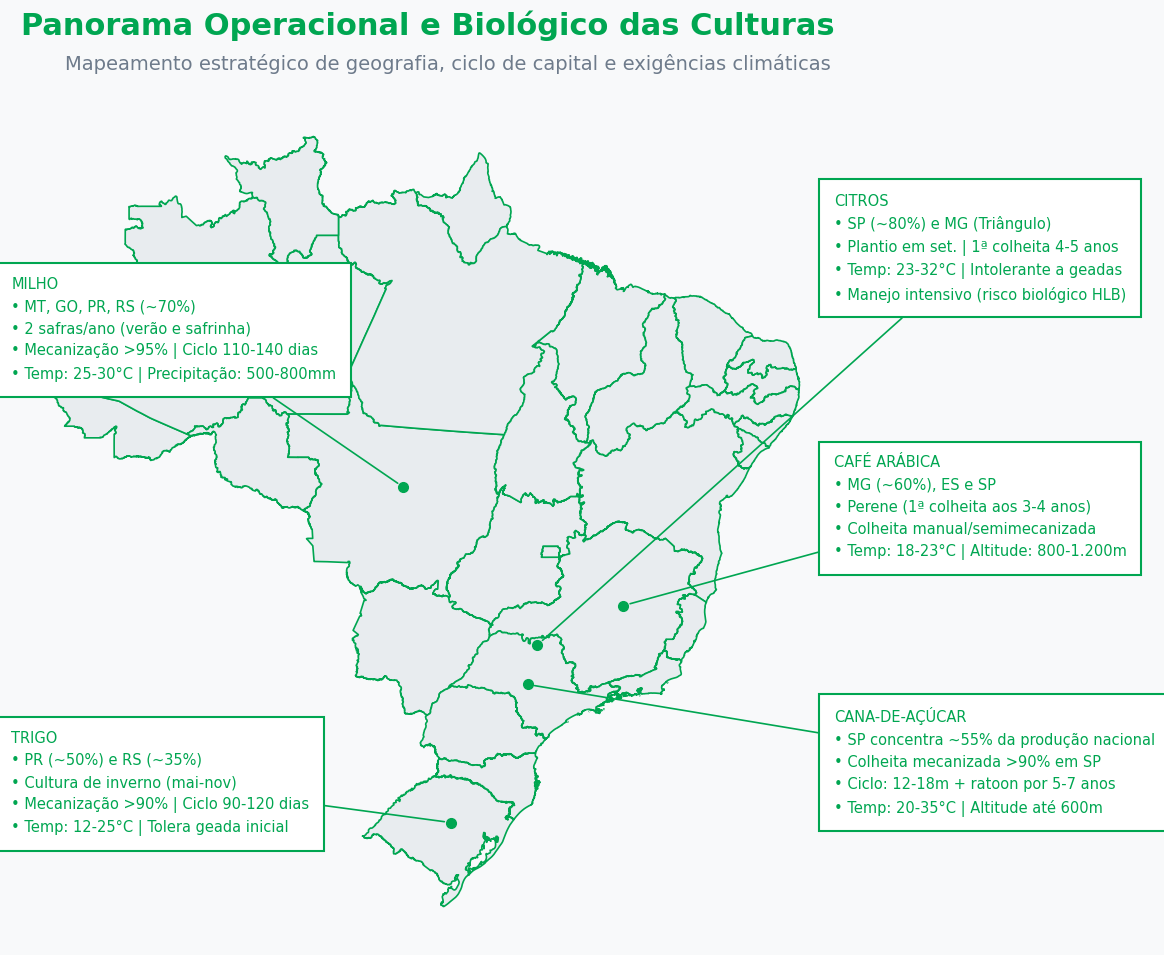

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Carregar o GeoJSON
url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
br_states = gpd.read_file(url_geojson)

# 2. Identidade Visual L.E.K.
LEK_GREEN = "#00A651"
LEK_NAVY = "#1A2744"
LEK_BG = "#F8F9FA"
LEK_LIGHT_GRAY = "#E8ECEF"
LEK_GRAY = "#6E7B8B"

# 3. Configuração do Canvas
fig, ax = plt.subplots(figsize=(16, 11))
fig.patch.set_facecolor(LEK_BG)
ax.axis('off')

# Plota o mapa base limpo
br_states.plot(ax=ax, color=LEK_LIGHT_GRAY, edgecolor=LEK_GREEN, linewidth=1.2)

# 4. Estrutura de Dados das Anotações (Callouts)
# xy: Coordenada do marcador no estado (Long, Lat)
# xytext: Coordenada onde a caixa de texto será ancorada no canvas
annotations = {
    "Milho": {
        "text": "MILHO\n• MT, GO, PR, RS (~70%)\n• 2 safras/ano (verão e safrinha)\n• Mecanização >95% | Ciclo 110-140 dias\n• Temp: 25-30°C | Precipitação: 500-800mm",
        "xy": (-55.5, -12.5),    # Alvo: Mato Grosso
        "xytext": (-76, -7)      # Posição: Noroeste
    },
    "Trigo": {
        "text": "TRIGO\n• PR (~50%) e RS (~35%)\n• Cultura de inverno (mai-nov)\n• Mecanização >90% | Ciclo 90-120 dias\n• Temp: 12-25°C | Tolera geada inicial",
        "xy": (-53.0, -29.5),    # Alvo: Rio Grande do Sul
        "xytext": (-76, -30)     # Posição: Sudoeste
    },
    "Citros": {
        "text": "CITROS\n• SP (~80%) e MG (Triângulo)\n• Plantio em set. | 1ª colheita 4-5 anos\n• Temp: 23-32°C | Intolerante a geadas\n• Manejo intensivo (risco biológico HLB)",
        "xy": (-48.5, -20.5),    # Alvo: Divisa SP/MG
        "xytext": (-33, -3)      # Posição: Nordeste
    },
    "Café Arábica": {
        "text": "CAFÉ ARÁBICA\n• MG (~60%), ES e SP\n• Perene (1ª colheita aos 3-4 anos)\n• Colheita manual/semimecanizada\n• Temp: 18-23°C | Altitude: 800-1.200m",
        "xy": (-44.0, -18.5),    # Alvo: Minas Gerais
        "xytext": (-33, -16)     # Posição: Leste
    },
    "Cana-de-Açúcar": {
        "text": "CANA-DE-AÇÚCAR\n• SP concentra ~55% da produção nacional\n• Colheita mecanizada >90% em SP\n• Ciclo: 12-18m + ratoon por 5-7 anos\n• Temp: 20-35°C | Altitude até 600m",
        "xy": (-49.0, -22.5),    # Alvo: São Paulo
        "xytext": (-33, -29)     # Posição: Sudeste
    }
}

# 5. Renderização dos Callouts
for crop, info in annotations.items():
    ax.annotate(
        info["text"],
        xy=info["xy"], xycoords='data',
        xytext=info["xytext"], textcoords='data',
        fontsize=10.5, color=LEK_GREEN, linespacing=1.6,
        bbox=dict(boxstyle="square,pad=1", fc="white", ec=LEK_GREEN, lw=1.5),
        arrowprops=dict(arrowstyle="-", color=LEK_GREEN, lw=1.2, shrinkA=0, shrinkB=5),
        ha='left'
    )
    # Marcador no mapa
    ax.plot(info["xy"][0], info["xy"][1], 'o', color=LEK_GREEN, markersize=7)

# 6. Títulos e Output
plt.suptitle("Panorama Operacional e Biológico das Culturas", 
             fontsize=22, fontweight='bold', color=LEK_GREEN, y=0.96)
plt.title("Mapeamento estratégico de geografia, ciclo de capital e exigências climáticas", 
          fontsize=14, color=LEK_GRAY, pad=20)

plt.savefig("infografico_operacional_lek.png", dpi=300, bbox_inches='tight', facecolor=LEK_DARK_GREEN)
print("Infográfico renderizado com sucesso: infografico_operacional_lek.png")

One-pager renderizado com sucesso: mapa_sintese_colorido.png


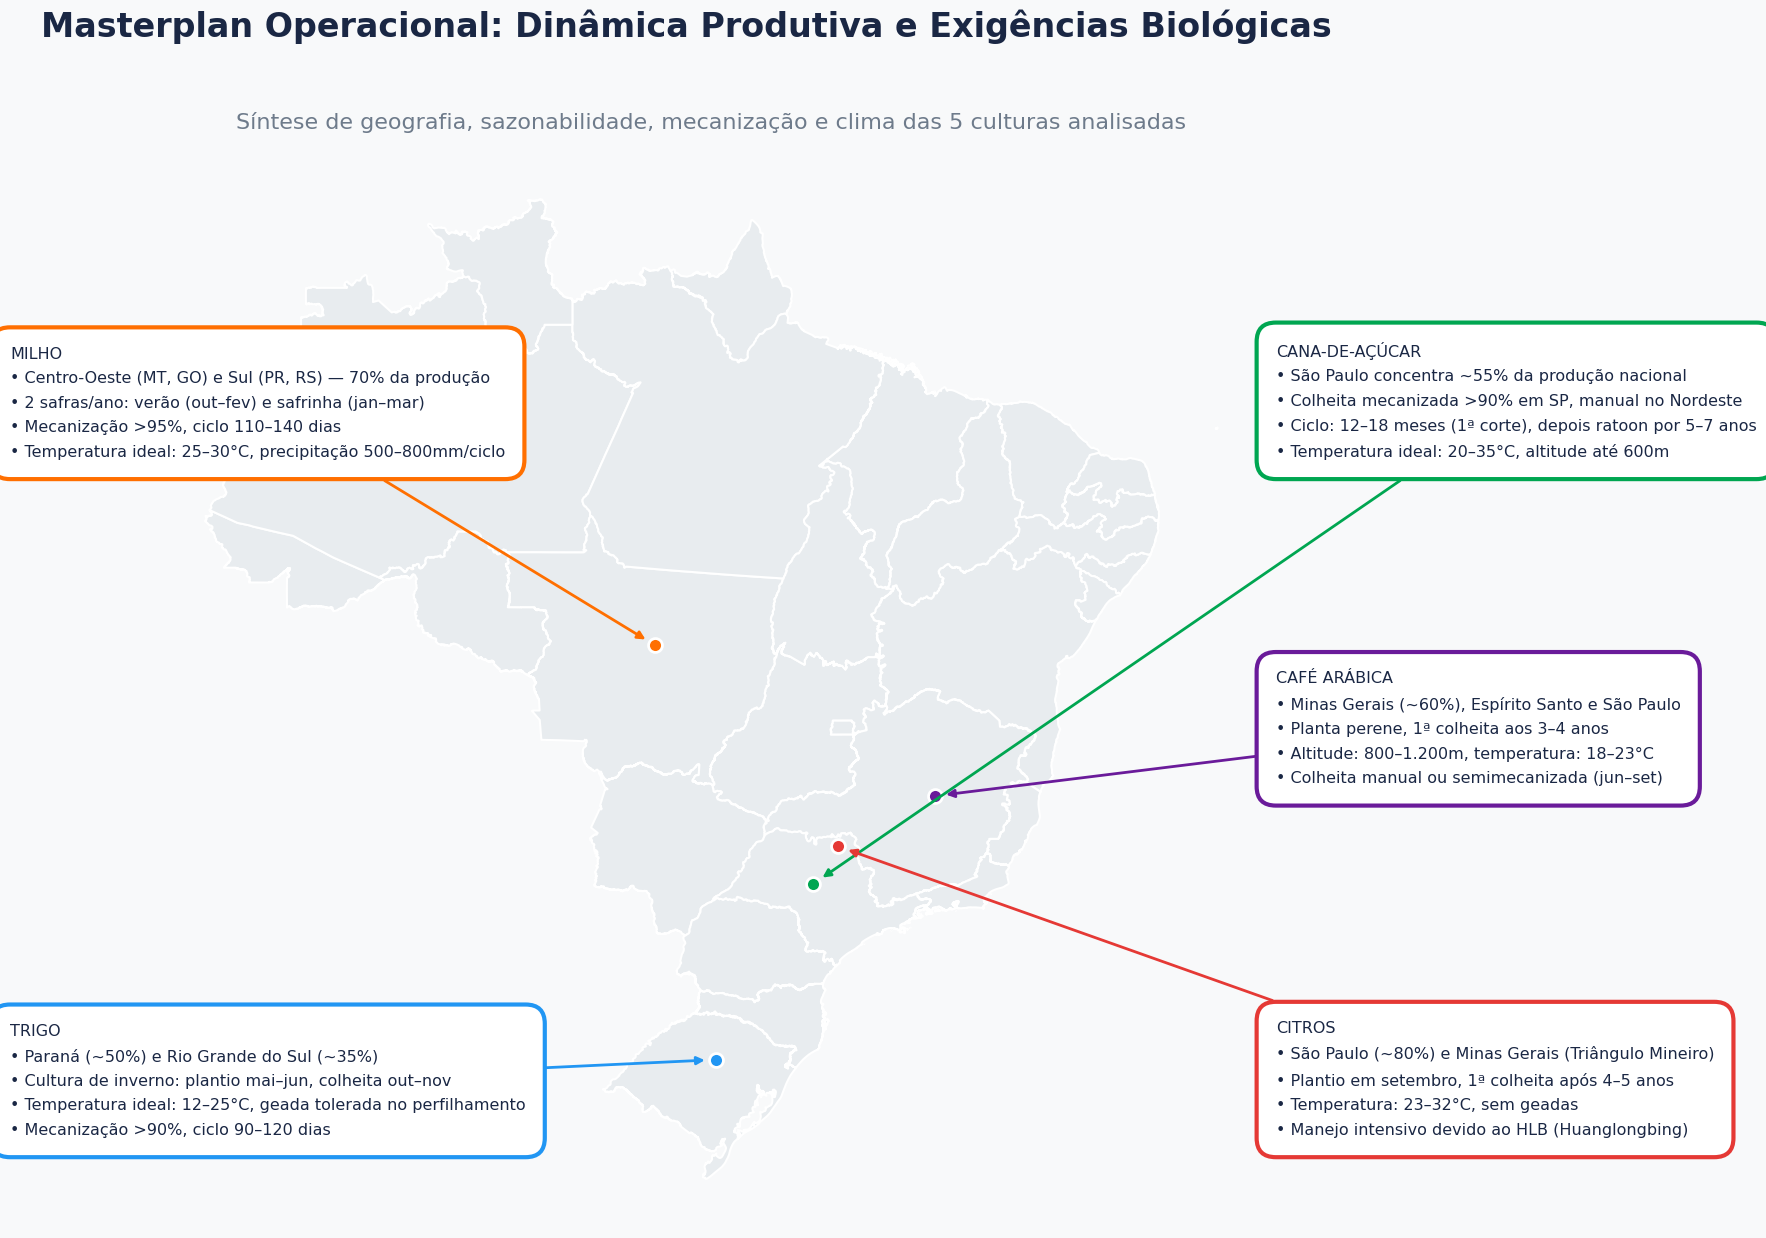

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Carregamento da Base Geográfica
url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
br_states = gpd.read_file(url_geojson)

# 2. Paleta de Cores Estendida (Color Coding)
COLORS = {
    "Milho": "#FF6F00",         # Laranja
    "Cana-de-Açúcar": "#00A651", # Verde L.E.K.
    "Café Arábica": "#6A1B9A",   # Roxo
    "Trigo": "#2196F3",          # Azul
    "Citros": "#E53935",         # Vermelho
    "Base": "#E8ECEF",           # Cinza Claro (Fundo do Mapa)
    "BG": "#F8F9FA"              # Fundo do Slide
}

# 3. Configuração do Canvas (Tamanho grande para comportar os textos)
fig, ax = plt.subplots(figsize=(20, 14))
fig.patch.set_facecolor(COLORS["BG"])
ax.axis('off')

# Plota o mapa base
br_states.plot(ax=ax, color=COLORS["Base"], edgecolor='white', linewidth=1.5)

# 4. Estrutura de Dados das Anotações (Textos exatos fornecidos)
# xy: Coordenada alvo no mapa (Long, Lat)
# xytext: Coordenada da caixa de texto
annotations = {
    "Milho": {
        "text": "MILHO\n• Centro-Oeste (MT, GO) e Sul (PR, RS) — 70% da produção\n• 2 safras/ano: verão (out–fev) e safrinha (jan–mar)\n• Mecanização >95%, ciclo 110–140 dias\n• Temperatura ideal: 25–30°C, precipitação 500–800mm/ciclo",
        "xy": (-55.5, -12.5), 
        "xytext": (-82, -5),
        "color": COLORS["Milho"]
    },
    "Trigo": {
        "text": "TRIGO\n• Paraná (~50%) e Rio Grande do Sul (~35%)\n• Cultura de inverno: plantio mai–jun, colheita out–nov\n• Temperatura ideal: 12–25°C, geada tolerada no perfilhamento\n• Mecanização >90%, ciclo 90–120 dias",
        "xy": (-53.0, -29.0), 
        "xytext": (-82, -32),
        "color": COLORS["Trigo"]
    },
    "Cana-de-Açúcar": {
        "text": "CANA-DE-AÇÚCAR\n• São Paulo concentra ~55% da produção nacional\n• Colheita mecanizada >90% em SP, manual no Nordeste\n• Ciclo: 12–18 meses (1ª corte), depois ratoon por 5–7 anos\n• Temperatura ideal: 20–35°C, altitude até 600m",
        "xy": (-49.0, -22.0), 
        "xytext": (-30, -5),
        "color": COLORS["Cana-de-Açúcar"]
    },
    "Café Arábica": {
        "text": "CAFÉ ARÁBICA\n• Minas Gerais (~60%), Espírito Santo e São Paulo\n• Planta perene, 1ª colheita aos 3–4 anos\n• Altitude: 800–1.200m, temperatura: 18–23°C\n• Colheita manual ou semimecanizada (jun–set)",
        "xy": (-44.0, -18.5), 
        "xytext": (-30, -18),
        "color": COLORS["Café Arábica"]
    },
    "Citros": {
        "text": "CITROS\n• São Paulo (~80%) e Minas Gerais (Triângulo Mineiro)\n• Plantio em setembro, 1ª colheita após 4–5 anos\n• Temperatura: 23–32°C, sem geadas\n• Manejo intensivo devido ao HLB (Huanglongbing)",
        "xy": (-48.0, -20.5), 
        "xytext": (-30, -32),
        "color": COLORS["Citros"]
    }
}

# 5. Renderização dos Callouts Coloridos
for crop, info in annotations.items():
    # Desenha o marcador colorido no mapa
    ax.plot(info["xy"][0], info["xy"][1], 'o', color=info["color"], markersize=10, markeredgecolor='white', markeredgewidth=2)
    
    # Desenha a caixa de texto
    ax.annotate(
        info["text"],
        xy=info["xy"], xycoords='data',
        xytext=info["xytext"], textcoords='data',
        fontsize=11.5, color="#1A2744", linespacing=1.8,
        bbox=dict(boxstyle="round,pad=1.2", fc="white", ec=info["color"], lw=3),
        arrowprops=dict(arrowstyle="-|>", color=info["color"], lw=2, shrinkA=0, shrinkB=8),
        ha='left'
    )

# 6. Cabeçalho Executivo
plt.suptitle("Masterplan Operacional: Dinâmica Produtiva e Exigências Biológicas", 
             fontsize=24, fontweight='bold', color="#1A2744", y=0.98)
plt.title("Síntese de geografia, sazonabilidade, mecanização e clima das 5 culturas analisadas", 
          fontsize=16, color="#6E7B8B", pad=15)

plt.savefig("mapa_sintese_colorido.png", dpi=300, bbox_inches='tight', facecolor=COLORS["BG"])
print("One-pager renderizado com sucesso: mapa_sintese_colorido.png")

In [29]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from shapely.geometry import Point
import warnings

warnings.filterwarnings("ignore")


# 1. PROCESSAMENTO DE DADOS (Extração Dinâmica dos CSVs da CONAB)
# =============================================================================
print("Lendo bases de dados e extraindo safra 2025/26...")

df_cana = pd.read_csv('LevantamentoCana.csv', sep=';', encoding='latin1')
df_cafe = pd.read_csv('SerieHistoricaCafe.csv', sep=';', encoding='latin1')
df_graos = pd.read_csv('SerieHistoricaGraos.csv', sep=';', encoding='latin1')
# Limpeza básica de formatação das strings (remove espaços em branco)
df_cana['ano_agricola'] = df_cana['ano_agricola'].astype(str).str.strip()
df_cafe['ano_agricola'] = df_cafe['ano_agricola'].astype(str).str.strip()
df_graos['ano_agricola'] = df_graos['ano_agricola'].astype(str).str.strip()
df_graos['produto'] = df_graos['produto'].astype(str).str.strip()

# --- Cana-de-açúcar (2025/26) ---
cana_2025 = df_cana[df_cana['ano_agricola'] == '2025/26']
# Pega sempre a estimativa/levantamento mais recente por UF
idx_cana = cana_2025.groupby('uf')['id_levantamento'].idxmax() 
cana_2025 = cana_2025.loc[idx_cana]
vol_cana = cana_2025['producao_mil_t'].sum()
dist_cana = (cana_2025.groupby('uf')['producao_mil_t'].sum() / vol_cana).to_dict()

# --- Café EXCLUSIVO Arábica (2026 | ID = 7498) ---
arabica_2026 = df_cafe[(df_cafe['ano_agricola'] == '2026') & (df_cafe['id_produto'] == 7498)]
vol_arabica = arabica_2026['producao_mil_t'].sum()
dist_arabica = (arabica_2026.groupby('uf')['producao_mil_t'].sum() / vol_arabica).to_dict()

# --- Milho Total (2025/26 | Soma 1ª, 2ª e 3ª Safras) ---
milho_2025 = df_graos[(df_graos['ano_agricola'] == '2025/26') & (df_graos['produto'] == 'MILHO')]
vol_milho = milho_2025['producao_mil_t'].sum()
dist_milho = (milho_2025.groupby('uf')['producao_mil_t'].sum() / vol_milho).to_dict()

# --- Trigo (2025) ---
trigo_2025 = df_graos[(df_graos['ano_agricola'] == '2025') & (df_graos['produto'] == 'TRIGO')]
vol_trigo = trigo_2025['producao_mil_t'].sum()
dist_trigo = (trigo_2025.groupby('uf')['producao_mil_t'].sum() / vol_trigo).to_dict()

# --- Consolidação para o Motor de Mapas ---
crop_data = {
    "Cana-de-açúcar": {
        "volume_nacional": vol_cana, "distribuicao": dist_cana, "unidade": "mil ton."
    },
    "Café (Arábica)": {
        "volume_nacional": vol_arabica, "distribuicao": dist_arabica, "unidade": "mil sacas" # CONAB relata café em sacas
    },
    "Milho": {
        "volume_nacional": vol_milho, "distribuicao": dist_milho, "unidade": "mil ton."
    },
    "Trigo": {
        "volume_nacional": vol_trigo, "distribuicao": dist_trigo, "unidade": "mil ton."
    },
    "Citros": { # Citros não está nos CSVs de grãos, mantida base estática IBGE
        "volume_nacional": 14500, 
        "distribuicao": {"SP": 0.770, "MG": 0.060, "PR": 0.050, "BA": 0.030, "SE": 0.030, "RS": 0.020},
        "unidade": "mil ton."
    }
}

# =============================================================================
# 2. MOTOR DE RENDERIZAÇÃO L.E.K. (Mapas de Densidade)
# =============================================================================
LEK_GREEN = "#00A651"
LEK_DARK_GREEN = "#004D2C"
LEK_NAVY = "#1A2744"
LEK_BG = "#F8F9FA"
LEK_LIGHT_GREEN = "#E0F2E9"
LEK_GRAY = "#6E7B8B"

def generate_dots(polygon, num_dots):
    points = []
    minx, miny, maxx, maxy = polygon.bounds
    while len(points) < num_dots:
        pnt = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if polygon.contains(pnt):
            points.append(pnt)
    return points

url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
br_states = gpd.read_file(url_geojson)

TOTAL_PONTOS_VISUAIS = 2000

for crop, info in crop_data.items():
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor(LEK_BG)
    
    total_vol = info["volume_nacional"]
    dot_value = total_vol / TOTAL_PONTOS_VISUAIS 
    
    # Formatação numérica PT-BR
    dot_value_str = f"{dot_value:,.0f}".replace(",", ".")
    unidade_medida = info["unidade"]
    
    ax.set_title(f"Densidade de Produção 2025/26 – {crop}", 
                 fontsize=26, fontweight='bold', color=LEK_GREEN, pad=15)
    ax.axis('off')
    
    br_states.plot(ax=ax, color=LEK_LIGHT_GREEN, edgecolor=LEK_GREEN, linewidth=0.5)
    
    shares = info["distribuicao"]
    for sigla, share in shares.items():
        if pd.isna(share) or share <= 0:
            continue
            
        state_geom = br_states[br_states['sigla'] == sigla]
        
        if not state_geom.empty:
            poly = state_geom.geometry.iloc[0]
            num_dots = int(TOTAL_PONTOS_VISUAIS * share)
            
            if num_dots > 0:
                dots = generate_dots(poly, num_dots)
                x = [d.x for d in dots]
                y = [d.y for d in dots]
                ax.scatter(x, y, s=2.5, color=LEK_DARK_GREEN, alpha=0.6, zorder=5)

    # Legenda Dinâmica e Limpa
    legend_dot = mlines.Line2D([], [], color='none', marker='o',
                               markerfacecolor=LEK_DARK_GREEN, markeredgecolor='none',
                               markersize=4, label=f'1 ponto = {dot_value_str} {unidade_medida}')
    
    leg = ax.legend(handles=[legend_dot], 
                    title="Interpretação do Mapa:", 
                    loc='lower right', 
                    frameon=False, 
                    bbox_to_anchor=(1.1, 0.1)) 
    
    leg.get_title().set_color(LEK_GREEN)
    leg.get_title().set_fontweight('bold')
    leg.get_title().set_fontsize(10)
    for text in leg.get_texts():
        text.set_color(LEK_GRAY)
        text.set_fontsize(14)

    plt.tight_layout()
    
    file_suffix = crop.split()[0].lower().replace("-", "_").replace("ç", "c").replace("á", "a").replace("é", "e")
    filename = f"mapa_densidade_lek_{file_suffix}.png"
    
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor=LEK_BG)
    plt.close(fig)
    print(f"✓ Mapa gerado: {filename}")

Lendo bases de dados e extraindo safra 2025/26...
✓ Mapa gerado: mapa_densidade_lek_cana_de_acúcar.png
✓ Mapa gerado: mapa_densidade_lek_cafe.png
✓ Mapa gerado: mapa_densidade_lek_milho.png
✓ Mapa gerado: mapa_densidade_lek_trigo.png
✓ Mapa gerado: mapa_densidade_lek_citros.png


## Gráficos

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. PREPARAÇÃO DOS DADOS ──────────────────────────────────────────────────
file_path = "Base LEK.xlsx"
df1 = pd.read_excel(file_path, sheet_name=0)
df1['ano_int'] = df1['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')

crop_map = {
    'Café': 'Café Arábica',
    'Cana': 'Cana de Açúcar',
    'Citrus': 'Citros',
    'Milho': 'Milho',
    'Trigo': 'Trigo'
}

# Cores em ordem alfabética (Degradê do Escuro ao Claro)
colors = ['#166800', '#1f8f00', '#27b300', '#2fd800', '#38ff00']
sorted_crops = sorted(crop_map.items(), key=lambda item: item[1])
color_mapping = {crop_key: colors[i] for i, (crop_key, _) in enumerate(sorted_crops)}

# Variáveis para armazenar os dados calculados
cagrs = {}
market_shares = {}

for crop_key, crop_name in crop_map.items():
    data = df1[df1['Commodities'] == crop_key].sort_values('ano_int')
    x = data['ano_int'].astype(int).values
    y = data['MarketShareProdução (%)'].values
    
    # Tratamento da Cana de Açúcar (Lendo Exportação e convertendo)
    if crop_key == 'Cana':
        if y.max() < 0.01:
            y = data['MarketShareExportação (%)'].values
        if y.max() > 0 and y.max() < 2:  
            y = y * 100
            
    market_shares[crop_name] = {'x': x, 'y': y, 'color': color_mapping[crop_key]}
    
    # Cálculo do CAGR
    val_0 = y[0]
    val_n = y[-1]
    n_years = len(x) - 1
    cagr = ((val_n / val_0) ** (1 / n_years) - 1) * 100 if val_0 > 0 else 0
    cagrs[crop_name] = cagr

# ── 2. PLOTAGEM DOS GRÁFICOS UNIFICADOS ──────────────────────────────────────
def plot_combined_charts():
    # ── GRÁFICO 1: Evolução do Market Share (Linhas) ──
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    
    for crop_name, data in market_shares.items():
        if len(data['x']) < 5: continue
        ax1.plot(data['x'], data['y'], label=crop_name, color=data['color'], linewidth=2.5, marker='o')
        
    ax1.set_title("Evolução do Market Share de Produção (2018-2025)\n%", loc='left', fontsize=14, fontweight='bold', color='#126E3A')
    
    # Formatação Visual (L.E.K. clean)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False) # Remove linha do Eixo Y
    ax1.spines['bottom'].set_color('#E8ECEF')
    ax1.grid(axis='y', color='#E8ECEF', linestyle='--', linewidth=0.7) # Grid horizontal leve
    
    # Legenda embaixo
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False)
    
    plt.tight_layout()
    plt.savefig('Evolucao_Market_Share_Linhas.png', dpi=300)
    plt.close()

    # ── GRÁFICO 2: CAGR Comparativo (Barras Horizontais) ──
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    # Ordena pelo maior CAGR (crescimento) até o menor (queda)
    sorted_cagrs = sorted(cagrs.items(), key=lambda item: item[1], reverse=True)
    names = [item[0] for item in sorted_cagrs]
    vals = [item[1] for item in sorted_cagrs]
    bar_colors = [market_shares[name]['color'] for name in names]
    
    y_pos = np.arange(len(names))
    bars = ax2.barh(y_pos, vals, color=bar_colors, height=0.6)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(names, fontsize=11)
    ax2.invert_yaxis()  # O maior fica no topo
    
    # Formatação Visual
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_color('#E8ECEF')
    ax2.axvline(0, color='black', linewidth=1) # Linha do Zero central
    
    # Adiciona os valores (+X,X%) do lado das barras
    for bar in bars:
        width = bar.get_width()
        # Ajusta a posição do texto se for positivo ou negativo
        label_x = width + 0.1 if width > 0 else width - 0.1
        ha = 'left' if width > 0 else 'right'
        ax2.text(label_x, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%".replace('.', ','),
                 ha=ha, va='center', fontsize=11, color='#555555')

    ax2.set_title("CAGR Market Share nas Culturas (2018-2025)\n%", loc='left', fontsize=14, fontweight='bold', color='#126E3A')
    
    plt.tight_layout()
    plt.savefig('CAGR_Comparativo_Barras.png', dpi=300)
    plt.close()

if __name__ == "__main__":
    plot_combined_charts()
    print("Gráficos de evolução unificados gerados com sucesso!")

Gráficos de evolução unificados gerados com sucesso!


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. PREPARAÇÃO DOS DADOS ──────────────────────────────────────────────────
# Certifique-se de que o nome do arquivo está correto (ex: "Base LEK (1).xlsx")
file_path = "Base LEK.xlsx" 
df1 = pd.read_excel(file_path, sheet_name=0)
df1['ano_int'] = df1['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')

crop_map = {
    'Café': 'Café Arábica',
    'Cana': 'Cana de Açúcar',
    'Citrus': 'Citros',
    'Milho': 'Milho',
    'Trigo': 'Trigo'
}

# Cores em ordem alfabética (Degradê do Escuro ao Claro)
colors = [ "#073700", "#236E03", "#57A50E", '#2fd800', '#38ff00']
sorted_crops = sorted(crop_map.items(), key=lambda item: item[1])
color_mapping = {crop_key: colors[i] for i, (crop_key, _) in enumerate(sorted_crops)}

# Variáveis para armazenar os dados calculados
cagrs = {}
market_shares = {}

for crop_key, crop_name in crop_map.items():
    data = df1[df1['Commodities'] == crop_key].sort_values('ano_int')
    x = data['ano_int'].astype(int).values
    y = data['MarketShareProdução (%)'].values
    
    # Tratamento da Cana de Açúcar (Lendo Exportação e convertendo)
    if crop_key == 'Cana':
        if y.max() < 0.01:
            y = data['MarketShareExportação (%)'].values
        if y.max() > 0 and y.max() < 2:  
            y = y * 100
            
    market_shares[crop_name] = {'x': x, 'y': y, 'color': color_mapping[crop_key]}
    
    # Cálculo do CAGR
    val_0 = y[0]
    val_n = y[-1]
    n_years = len(x) - 1
    cagr = ((val_n / val_0) ** (1 / n_years) - 1) * 100 if val_0 > 0 else 0
    cagrs[crop_name] = cagr

# ── 2. PLOTAGEM DOS GRÁFICOS UNIFICADOS ──────────────────────────────────────
def plot_combined_charts():
    # ── GRÁFICO 1: Evolução do Market Share (Linhas) ──
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    
    for crop_name, data in market_shares.items():
        if len(data['x']) < 5: continue
        ax1.plot(data['x'], data['y'], label=crop_name, color=data['color'], linewidth=2.5, marker='o')
        
    # Título centralizado (loc='center')
    ax1.set_title("Evolução do Market Share de Produção (2018-2025)\n%", loc='center', fontsize=14, fontweight='bold', color='#126E3A')
    
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_color('#E8ECEF')
    ax1.grid(axis='y', color='#E8ECEF', linestyle='--', linewidth=0.7)
    
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False)
    
    plt.tight_layout()
    plt.savefig('Evolucao_Market_Share_Linhas.png', dpi=300)
    plt.close()

    # ── GRÁFICO 2: CAGR Comparativo (Barras Horizontais) ──
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    sorted_cagrs = sorted(cagrs.items(), key=lambda item: item[1], reverse=True)
    names = [item[0] for item in sorted_cagrs]
    vals = [item[1] for item in sorted_cagrs]
    bar_colors = [market_shares[name]['color'] for name in names]
    
    y_pos = np.arange(len(names))
    bars = ax2.barh(y_pos, vals, color=bar_colors, height=0.6)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(names, fontsize=11)
    ax2.invert_yaxis()
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_color('#E8ECEF')
    ax2.axvline(0, color='black', linewidth=1)
    
    # AJUSTE DE ESPAÇO: Aumenta a margem do eixo X para os números não sobreporem o texto
    xmin, xmax = min(vals), max(vals)
    ax2.set_xlim(xmin - 1.5, xmax + 1.5)
    
    for bar in bars:
        width = bar.get_width()
        # label_x: maior distanciamento (0.4) para evitar sobreposição
        label_x = width + 0.4 if width > 0 else width - 0.4
        ha = 'left' if width > 0 else 'right'
        ax2.text(label_x, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%".replace('.', ','),
                 ha=ha, va='center', fontsize=11, color='#555555', fontweight='bold')

    # Título centralizado (loc='center')
    ax2.set_title("CAGR Market Share nas Culturas (2018-2025)\n%", loc='center', fontsize=14, fontweight='bold', color='#126E3A')
    
    plt.tight_layout()
    plt.savefig('CAGR_Comparativo_Barras.png', dpi=300)
    plt.close()

if __name__ == "__main__":
    plot_combined_charts()
    print("Gráficos gerados com sucesso.")

Gráficos gerados com sucesso.


## Gráficos obrigatórios

Gráfico salvo com sucesso como 'receita_relativa.png'


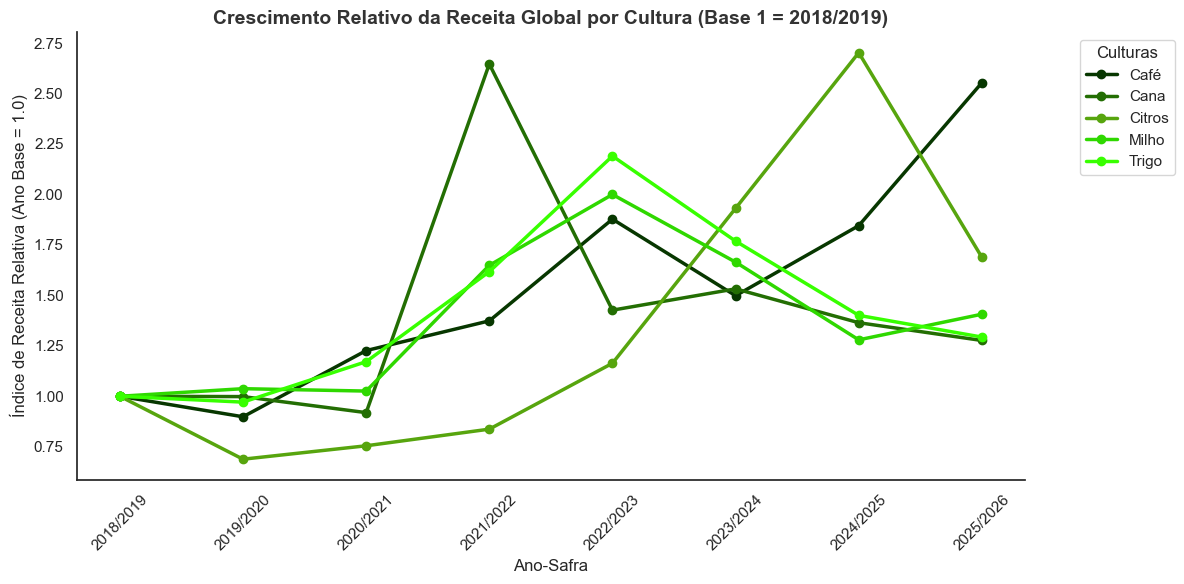

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class MarketDataVisualizer:
    def __init__(self, file_path: str, sheet_name: str = 'Base Geral'):
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.df = None
        
    def load_and_clean_data(self):
        """Carrega a base do Excel e realiza a limpeza inicial."""
        xls = pd.ExcelFile(self.file_path)
        df = pd.read_excel(xls, self.sheet_name)
        
        # Drop de nulos nas colunas de chave primária para a análise
        df = df.dropna(subset=['Ano', 'Commodities'])
        
        # Ordenação para garantir que a linha do tempo (Ano) esteja sequencial
        self.df = df.sort_values(by=['Commodities', 'Ano'])
        return self.df

    def plot_relative_revenue(self, output_filename: str = 'receita_relativa.png'):
        """Calcula o índice relativo e gera o gráfico com a paleta específica."""
        if self.df is None:
            self.load_and_clean_data()
            
        # Calcula a Receita Relativa: divide a receita de cada ano pela receita do ano 0 (1ª linha do grupo)
        self.df['Receita Relativa'] = self.df.groupby('Commodities')['Receita (global) - mil U$D'].transform(lambda x: x / x.iloc[0])

        # Dicionário com o mapeamento exato da paleta de cores fornecida
        color_map = {
            'Café': '#073700',
            'Cana': '#236E03',
            'Citros': '#57A50E',
            'Milho': '#2fd800',
            'Trigo': '#38ff00'
        }

        # Configuração do visual limpo SEM GRID (estilo "white")
        sns.set_theme(style="white", rc={"axes.facecolor": "white"})
        plt.figure(figsize=(12, 6))

        # Iteração para garantir que cada commodity puxe a cor exata do dicionário
        for commodity, color in color_map.items():
            if commodity in self.df['Commodities'].unique():
                subset = self.df[self.df['Commodities'] == commodity]
                plt.plot(subset['Ano'], subset['Receita Relativa'], 
                         marker='o', label=commodity, color=color, linewidth=2.5)

        # Configurações de texto e eixos
        plt.title("Crescimento Relativo da Receita Global por Cultura (Base 1 = 2018/2019)", 
                  fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel("Ano-Safra", fontsize=12)
        plt.ylabel("Índice de Receita Relativa (Ano Base = 1.0)", fontsize=12)
        plt.legend(title='Culturas', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)

        # Remove as bordas superior e direita do gráfico para um visual mais limpo
        sns.despine()

        # Ajuste de layout e salvamento
        plt.tight_layout()
        plt.savefig(output_filename, dpi=300)
        print(f"Gráfico salvo com sucesso como '{output_filename}'")
        plt.show()

# --- Entry Point ---
if __name__ == "__main__":
    # Instancia a classe passando o nome do arquivo
    visualizer = MarketDataVisualizer(file_path="Base LEK.xlsx")
    
    # Executa a geração do gráfico
    visualizer.plot_relative_revenue()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AgroMarketVisualizer:
    def __init__(self, file_path: str, sheet_name: str = 'Sheet1'):
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.df = None
        # Dicionário com a paleta de cores fornecida
        self.color_map = {
            'Café': '#073700',
            'Cana': '#236E03',
            'Citros': '#57A50E',
            'Milho': '#2fd800',
            'Trigo': '#38ff00'
        }
        
    def load_and_clean_data(self):
        """Carrega a base do Excel e realiza a limpeza inicial."""
        xls = pd.ExcelFile(self.file_path)
        df = pd.read_excel(xls, self.sheet_name)
        df = df.dropna(subset=['Ano', 'Commodities'])
        
        # Cria uma coluna numérica para facilitar o filtro de anos (ex: "2022/2023" -> 2022)
        df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')
        
        self.df = df.sort_values(by=['Commodities', 'ano_int'])
        
        # Configuração do grid corporativo limpo
        sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white", "grid.color": "#e0e0e0"})
        return self.df

    def plot_metric(self, y_column: str, title: str, ylabel: str, filename: str, use_log_scale: bool = False, start_year: int = None):
        """Método genérico para plotar métricas ao longo do tempo."""
        if self.df is None:
            self.load_and_clean_data()

        plt.figure(figsize=(12, 6))

        for commodity, color in self.color_map.items():
            if commodity in self.df['Commodities'].unique():
                subset = self.df[self.df['Commodities'] == commodity].copy()
                
                # Aplica o filtro de ano inicial, se fornecido
                if start_year is not None:
                    subset = subset[subset['ano_int'] >= start_year]
                
                # Só plota se ainda restarem dados após o filtro
                if not subset.empty:
                    plt.plot(subset['Ano'], subset[y_column], 
                             marker='o', label=commodity, color=color, linewidth=2.5)

        plt.title(title, fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel("Ano-Safra", fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.legend(title='Commodities', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        
        if use_log_scale:
            plt.yscale('log')
            plt.ylabel(f"{ylabel} - Escala Logarítmica", fontsize=12)

        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        print(f"Gráfico salvo com sucesso como '{filename}'")
        plt.close() # Alterado para plt.close() para não acumular gráficos na memória se rodar várias vezes

# --- Entry Point ---
if __name__ == "__main__":
    visualizer = AgroMarketVisualizer(file_path="Base LEK.xlsx")
    
    # 1. Histórico de Produção (em volume) com escala log -> TODO O HISTÓRICO
    visualizer.plot_metric(
        y_column='Produção (mil t)',
        title="Evolução da Produção em Volume (Milhares de Toneladas)",
        ylabel="Produção (mil t)",
        filename="producao_volume.png",
        use_log_scale=True,
        start_year=2022 # <-- Parâmetro adicionado aqui
    )
    
    # 2. Evolução da Área Plantada -> APENAS A PARTIR DE 2022
    visualizer.plot_metric(
        y_column='Área plantada (mil He)',
        title="Evolução da Área Plantada (Milhares de Hectares) a partir de 2022",
        ylabel="Área Plantada (mil He)",
        filename="area_plantada_2022_frente.png",
        start_year=2022 # <-- Parâmetro adicionado aqui
    )
    
    # 3. Market Share de Produção -> TODO O HISTÓRICO
    visualizer.plot_metric(
        y_column='MarketShareProdução (%)',
        title="Market Share de Produção Global (%)",
        ylabel="Market Share Produção (%)",
        filename="market_share_producao.png",
        start_year=2022 # <-- Parâmetro adicionado aqui
    )

Gráfico salvo com sucesso como 'producao_volume.png'
Gráfico salvo com sucesso como 'area_plantada_2022_frente.png'
Gráfico salvo com sucesso como 'market_share_producao.png'


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AgroMarketVisualizer:
    def __init__(self, file_path: str, sheet_name: str = 'Sheet1'):
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.df = None
        # Dicionário com a paleta de cores fornecida
        self.color_map = {
            'Café': '#073700',
            'Cana': '#236E03',
            'Citros': '#57A50E',
            'Milho': '#2fd800',
            'Trigo': '#38ff00'
        }
        
    def load_and_clean_data(self):
        """Carrega a base do Excel e realiza a limpeza inicial."""
        xls = pd.ExcelFile(self.file_path)
        df = pd.read_excel(xls, self.sheet_name)
        df = df.dropna(subset=['Ano', 'Commodities'])
        
        # Cria uma coluna numérica para facilitar o filtro de anos (ex: "2022/2023" -> 2022)
        df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')
        
        self.df = df.sort_values(by=['Commodities', 'ano_int'])
        
        # Configuração do visual limpo SEM GRID (estilo "white")
        sns.set_theme(style="white", rc={"axes.facecolor": "white"})
        return self.df

    def plot_metric(self, y_column: str, title: str, ylabel: str, filename: str, use_log_scale: bool = False, start_year: int = None, base_year: int = None):
        """Método genérico para plotar métricas ao longo do tempo."""
        if self.df is None:
            self.load_and_clean_data()

        plt.figure(figsize=(12, 6))

        for commodity, color in self.color_map.items():
            if commodity in self.df['Commodities'].unique():
                subset = self.df[self.df['Commodities'] == commodity].copy()
                
                # Aplica a lógica de Valor Relativo (Base 1.0) se um ano base for fornecido
                if base_year is not None:
                    base_row = subset[subset['ano_int'] == base_year]
                    if not base_row.empty:
                        base_val = base_row[y_column].iloc[0]
                        subset[y_column] = subset[y_column] / base_val
                    else:
                        # Se a cultura não tiver dados no ano base, pula a plotagem dela
                        continue
                
                # Aplica o filtro de ano inicial, se fornecido
                if start_year is not None:
                    subset = subset[subset['ano_int'] >= start_year]
                
                # Só plota se ainda restarem dados após o filtro
                if not subset.empty:
                    plt.plot(subset['Ano'], subset[y_column], 
                             marker='o', label=commodity, color=color, linewidth=2.5)

        plt.title(title, fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel("Ano-Safra", fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        
        # Legenda atualizada para "Culturas"
        plt.legend(title='Culturas', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        
        if use_log_scale:
            plt.yscale('log')
            plt.ylabel(f"{ylabel} - Escala Logarítmica", fontsize=12)

        # Remove as bordas superior e direita do gráfico para um visual mais limpo
        sns.despine()

        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        print(f"Gráfico salvo com sucesso como '{filename}'")
        plt.close() # Não acumula gráficos na memória

# --- Entry Point ---
if __name__ == "__main__":
    visualizer = AgroMarketVisualizer(file_path="Base LEK.xlsx")
    
    # 1. Histórico de Produção Relativo a 2018 -> SEM escala log
    visualizer.plot_metric(
        y_column='Produção (mil t)',
        title="Crescimento Relativo da Produção em Volume (Base 1 = 2018)",
        ylabel="Índice de Produção (Base 1.0)",
        filename="producao_volume_relativo_2018.png",
        use_log_scale=False,
        base_year=2018,
        start_year=None # Permitindo todo o histórico para visualizar o ano base
    )
    
    # 2. Evolução da Área Plantada -> APENAS A PARTIR DE 2022
    visualizer.plot_metric(
        y_column='Área plantada (mil He)',
        title="Evolução da Área Plantada (Milhares de Hectares) a partir de 2022",
        ylabel="Área Plantada (mil He)",
        filename="area_plantada_2022_frente.png",
        start_year=2022
    )
    
    # 3. Market Share de Produção -> TODO O HISTÓRICO
    visualizer.plot_metric(
        y_column='MarketShareProdução (%)',
        title="Market Share de Produção Global (%)",
        ylabel="Market Share Produção (%)",
        filename="market_share_producao.png",
        start_year=None # Retirado o limitador para mostrar todo o histórico
    )

Gráfico salvo com sucesso como 'producao_volume_relativo_2018.png'
Gráfico salvo com sucesso como 'area_plantada_2022_frente.png'
Gráfico salvo com sucesso como 'market_share_producao.png'


Gráfico salvo com sucesso como 'producao_global_relativa.png'


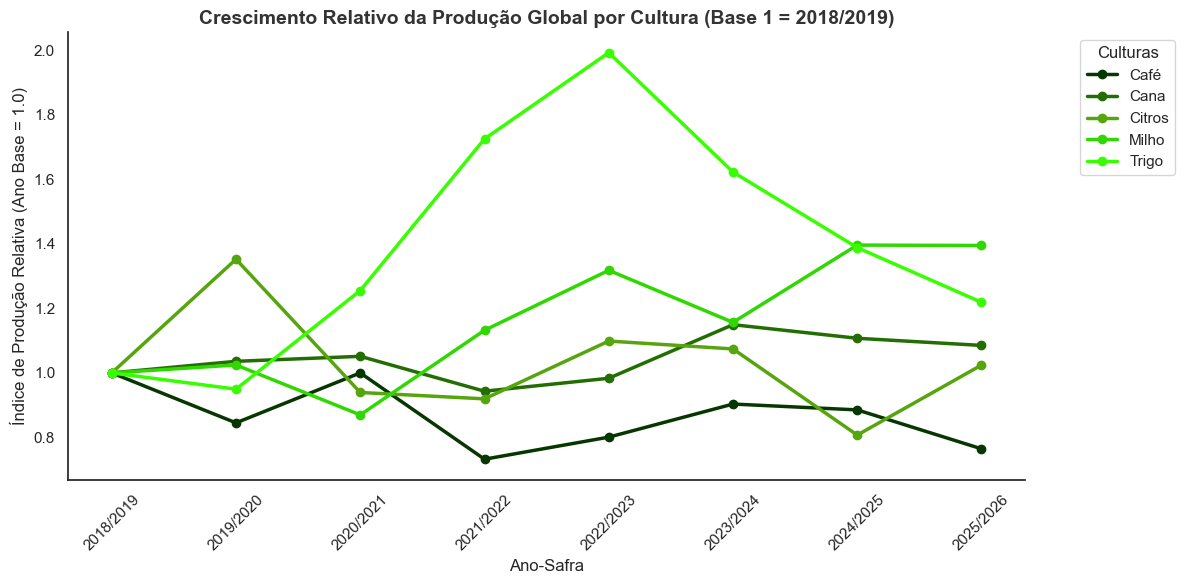

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class MarketDataVisualizer:
    def __init__(self, file_path: str, sheet_name: str = 'Base Geral'):
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.df = None
        
    def load_and_clean_data(self):
        """Carrega a base do Excel e realiza a limpeza inicial."""
        xls = pd.ExcelFile(self.file_path)
        df = pd.read_excel(xls, self.sheet_name)
        
        # Drop de nulos nas colunas de chave primária
        df = df.dropna(subset=['Ano', 'Commodities'])
        self.df = df.sort_values(by=['Commodities', 'Ano'])
        return self.df

    def plot_relative_production(self, output_filename: str = 'producao_global_relativa.png'):
        """Calcula o índice relativo direto da coluna de produção global e gera o gráfico."""
        if self.df is None:
            self.load_and_clean_data()
            
        # Calcula a Produção Relativa usando diretamente a 'Produção (mil t)' (que já é a global)
        self.df['Produção Relativa'] = self.df.groupby('Commodities')['Produção (mil t)'].transform(lambda x: x / x.iloc[0])

        # Paleta de cores corporativa mantida
        color_map = {
            'Café': '#073700',
            'Cana': '#236E03',
            'Citros': '#57A50E',
            'Milho': '#2fd800',
            'Trigo': '#38ff00'
        }

        # Estética de apresentação (slide-ready)
        sns.set_theme(style="white", rc={"axes.facecolor": "white"})
        plt.figure(figsize=(12, 6))

        for commodity, color in color_map.items():
            if commodity in self.df['Commodities'].unique():
                subset = self.df[self.df['Commodities'] == commodity]
                plt.plot(subset['Ano'], subset['Produção Relativa'], 
                         marker='o', label=commodity, color=color, linewidth=2.5)

        plt.title("Crescimento Relativo da Produção Global por Cultura (Base 1 = 2018/2019)", 
                  fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel("Ano-Safra", fontsize=12)
        plt.ylabel("Índice de Produção Relativa (Ano Base = 1.0)", fontsize=12)
        plt.legend(title='Culturas', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)

        sns.despine()

        plt.tight_layout()
        plt.savefig(output_filename, dpi=300)
        print(f"Gráfico salvo com sucesso como '{output_filename}'")

# Execução
visualizer = MarketDataVisualizer(file_path="Base LEK.xlsx")
visualizer.plot_relative_production()

In [81]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AgroMarketVisualizer:
    def __init__(self, file_path: str, sheet_name: str = 'Sheet1'):
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.df = None
        # Dicionário com a paleta de cores fornecida
        self.color_map = {
            'Café': '#073700',
            'Cana': '#236E03',
            'Citros': '#57A50E',
            'Milho': '#2fd800',
            'Trigo': '#38ff00'
        }
        
    def load_and_clean_data(self):
        """Carrega a base do Excel e realiza a limpeza inicial."""
        xls = pd.ExcelFile(self.file_path)
        df = pd.read_excel(xls, self.sheet_name)
        df = df.dropna(subset=['Ano', 'Commodities'])
        
        # Cria uma coluna numérica para facilitar o filtro de anos (ex: "2022/2023" -> 2022)
        df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')
        
        self.df = df.sort_values(by=['Commodities', 'ano_int'])
        
        # Configuração do visual limpo SEM GRID (estilo "white")
        sns.set_theme(style="white", rc={"axes.facecolor": "white"})
        return self.df

    def prepare_demand_metrics(self, prod_col: str, demand_col: str):
        """Cria as colunas calculadas de Relação Produção/Demanda e Desvio Padrão da Demanda."""
        if self.df is None:
            self.load_and_clean_data()
            
        # 1. Cria a Relação Produção sobre Demanda
        self.df['Producao_sobre_Demanda'] = self.df[prod_col] / self.df[demand_col]
        
        # 2. Cria o Desvio Padrão Móvel da Demanda (Janela de 3 anos) para ver a variação ao longo do tempo
        self.df['Desvio_Padrao_Demanda_3Anos'] = self.df.groupby('Commodities')[demand_col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std()
        )
        
        # Preenche os primeiros anos que não tem janela suficiente com 0 ou a variação inicial
        self.df['Desvio_Padrao_Demanda_3Anos'] = self.df['Desvio_Padrao_Demanda_3Anos'].fillna(0)

    def plot_metric(self, y_column: str, title: str, ylabel: str, filename: str, use_log_scale: bool = False, start_year: int = None, base_year: int = None):
        """Método genérico para plotar métricas ao longo do tempo."""
        if self.df is None:
            self.load_and_clean_data()

        plt.figure(figsize=(12, 6))

        for commodity, color in self.color_map.items():
            if commodity in self.df['Commodities'].unique():
                subset = self.df[self.df['Commodities'] == commodity].copy()
                
                # Aplica a lógica de Valor Relativo (Base 1.0) se um ano base for fornecido
                if base_year is not None:
                    base_row = subset[subset['ano_int'] == base_year]
                    if not base_row.empty:
                        base_val = base_row[y_column].iloc[0]
                        subset[y_column] = subset[y_column] / base_val
                    else:
                        continue
                
                # Aplica o filtro de ano inicial, se fornecido
                if start_year is not None:
                    subset = subset[subset['ano_int'] >= start_year]
                
                # Só plota se ainda restarem dados após o filtro
                if not subset.empty:
                    plt.plot(subset['Ano'], subset[y_column], 
                             marker='o', label=commodity, color=color, linewidth=2.5)

        plt.title(title, fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel("Ano-Safra", fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        
        # Legenda padronizada como "Culturas"
        plt.legend(title='Culturas', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        
        if use_log_scale:
            plt.yscale('log')
            plt.ylabel(f"{ylabel} - Escala Logarítmica", fontsize=12)

        # Remove as bordas superior e direita do gráfico para um visual mais limpo
        sns.despine()

        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        print(f"Gráfico salvo com sucesso como '{filename}'")
        plt.close()

# --- Entry Point ---
if __name__ == "__main__":
    visualizer = AgroMarketVisualizer(file_path="Base LEK.xlsx")
    
    # ATENÇÃO: Verifique se o nome dessas colunas correspondem exatamente ao seu Excel
    coluna_producao = 'Produção (mil t)'
    coluna_demanda = 'Demanda (mil t)' # <--- Altere aqui se na sua planilha estiver diferente (ex: 'Demanda Global')
    
    # Carrega os dados e calcula as métricas de demanda
    visualizer.prepare_demand_metrics(prod_col=coluna_producao, demand_col=coluna_demanda)
    
    # -------------------------------------------------------------
    # GRÁFICOS ORIGINAIS MANTIDOS
    # -------------------------------------------------------------
    visualizer.plot_metric(
        y_column='Produção (mil t)', title="Crescimento Relativo da Produção em Volume (Base 1 = 2018)",
        ylabel="Índice de Produção (Base 1.0)", filename="producao_volume_relativo_2018.png", base_year=2018
    )
    
    visualizer.plot_metric(
        y_column='Área plantada (mil He)', title="Evolução da Área Plantada (Milhares de Hectares) a partir de 2022",
        ylabel="Área Plantada (mil He)", filename="area_plantada_2022_frente.png", start_year=2022
    )
    
    visualizer.plot_metric(
        y_column='MarketShareProdução (%)', title="Market Share de Produção Global (%)",
        ylabel="Market Share Produção (%)", filename="market_share_producao.png"
    )

    # -------------------------------------------------------------
    # NOVOS GRÁFICOS SOLICITADOS
    # -------------------------------------------------------------
    
    # 4. Produção sobre Demanda Global
    visualizer.plot_metric(
        y_column='Producao_sobre_Demanda',
        title="Relação Produção / Demanda Global ao Longo do Tempo",
        ylabel="Razão (Produção ÷ Demanda)",
        filename="producao_sobre_demanda_global.png"
    )
    
    # 5. Desvio Padrão da Demanda (Variação da demanda em janelas móveis de 3 anos)
    visualizer.plot_metric(
        y_column='Desvio_Padrao_Demanda_3Anos',
        title="Variação da Demanda Global (Desvio Padrão Móvel - 3 Anos)",
        ylabel="Desvio Padrão da Demanda (mil t)",
        filename="desvio_padrao_demanda.png"
    )


KeyError: 'Demanda (mil t)'

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AgroMarketVisualizer:
    def __init__(self, file_path: str, sheet_name: str = 'Sheet1'): # Troque 'Sheet1' se a aba tiver outro nome
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.df = None
        # Dicionário com a paleta de cores exata fornecida
        self.color_map = {
            'Café': '#073700',
            'Cana': '#236E03',
            'Citros': '#57A50E',
            'Milho': '#2fd800',
            'Trigo': '#38ff00'
        }
        
    def load_and_clean_data(self):
        """Carrega a base do Excel e realiza a limpeza inicial."""
        xls = pd.ExcelFile(self.file_path)
        df = pd.read_excel(xls, self.sheet_name)
        df = df.dropna(subset=['Ano', 'Commodities'])
        
        # Cria uma coluna numérica para facilitar o filtro de anos (ex: "2018/2019" -> 2018)
        df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')
        
        self.df = df.sort_values(by=['Commodities', 'ano_int'])
        
        # Configuração do visual corporativo limpo SEM GRID (estilo "white")
        sns.set_theme(style="white", rc={"axes.facecolor": "white"})
        return self.df

    def prepare_demand_metrics(self, prod_col: str, demand_col: str):
        """Cria as colunas calculadas de Relação Produção/Demanda e Desvio Padrão da Demanda."""
        if self.df is None:
            self.load_and_clean_data()
            
        # 1. Cria a Relação Produção sobre Demanda Global
        # Ambas estão na mesma ordem de grandeza (milhares de toneladas), então a divisão é direta
        self.df['Producao_sobre_Demanda'] = self.df[prod_col] / self.df[demand_col]
        
        # 2. Cria o Desvio Padrão Móvel da Demanda (Janela de 3 anos)
        self.df['Desvio_Padrao_Demanda_3Anos'] = self.df.groupby('Commodities')[demand_col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std()
        )
        
        # Preenche os primeiros anos que não tem janela suficiente com 0
        self.df['Desvio_Padrao_Demanda_3Anos'] = self.df['Desvio_Padrao_Demanda_3Anos'].fillna(0)

    def plot_metric(self, y_column: str, title: str, ylabel: str, filename: str, use_log_scale: bool = False, start_year: int = None, base_year: int = None):
        """Método genérico para plotar métricas ao longo do tempo."""
        if self.df is None:
            self.load_and_clean_data()

        plt.figure(figsize=(12, 6))

        for commodity, color in self.color_map.items():
            if commodity in self.df['Commodities'].unique():
                subset = self.df[self.df['Commodities'] == commodity].copy()
                
                # Aplica a lógica de Valor Relativo (Base 1.0) se um ano base for fornecido
                if base_year is not None:
                    base_row = subset[subset['ano_int'] == base_year]
                    if not base_row.empty:
                        base_val = base_row[y_column].iloc[0]
                        subset[y_column] = subset[y_column] / base_val
                    else:
                        continue
                
                # Aplica o filtro de ano inicial, se fornecido
                if start_year is not None:
                    subset = subset[subset['ano_int'] >= start_year]
                
                # Só plota se ainda restarem dados após o filtro
                if not subset.empty:
                    plt.plot(subset['Ano'], subset[y_column], 
                             marker='o', label=commodity, color=color, linewidth=2.5)

        plt.title(title, fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel("Ano-Safra", fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        
        # Legenda atualizada para "Culturas"
        plt.legend(title='Culturas', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        
        if use_log_scale:
            plt.yscale('log')
            plt.ylabel(f"{ylabel} - Escala Logarítmica", fontsize=12)

        # Remove as bordas superior e direita do gráfico para um visual mais limpo
        sns.despine()

        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        print(f"Gráfico salvo com sucesso como '{filename}'")
        plt.close() # Não acumula gráficos na memória

# --- Entry Point ---
if __name__ == "__main__":
    # Instancia a classe passando o nome do arquivo da imagem
    visualizer = AgroMarketVisualizer(file_path="Base LEK.xlsx")
    
    # Nomes das colunas extraídos exatamente da imagem fornecida
    coluna_producao = 'Produção (mil t)'
    coluna_demanda = 'Demanda (Global) (1000 t)'
    
    # Carrega os dados e calcula as novas métricas
    visualizer.prepare_demand_metrics(prod_col=coluna_producao, demand_col=coluna_demanda)
    
    # -------------------------------------------------------------
    # 1. Histórico de Produção Relativo a 2018
    # -------------------------------------------------------------
    visualizer.plot_metric(
        y_column=coluna_producao,
        title="Crescimento Relativo da Produção em Volume (Base 1 = 2018)",
        ylabel="Índice de Produção (Base 1.0)",
        filename="producao_volume_relativo_2018.png",
        base_year=2018
    )
    
    # -------------------------------------------------------------
    # 2. Evolução da Área Plantada a partir de 2022
    # -------------------------------------------------------------
    visualizer.plot_metric(
        y_column='Área plantada (mil He)',
        title="Evolução da Área Plantada (Milhares de Hectares) a partir de 2022",
        ylabel="Área Plantada (mil He)",
        filename="area_plantada_2022_frente.png",
        start_year=2022
    )
    
    # -------------------------------------------------------------
    # 3. Market Share de Produção (Histórico Completo)
    # -------------------------------------------------------------
    visualizer.plot_metric(
        y_column='MarketShareProdução (%)',
        title="Market Share de Produção Global (%)",
        ylabel="Market Share Produção (%)",
        filename="market_share_producao.png"
    )

    # -------------------------------------------------------------
    # 4. Relação Produção sobre Demanda Global
    # -------------------------------------------------------------
    visualizer.plot_metric(
        y_column='Producao_sobre_Demanda',
        title="Relação Produção / Demanda Global ao Longo do Tempo",
        ylabel="Razão (Produção ÷ Demanda)",
        filename="producao_sobre_demanda_global.png"
    )
    
    # -------------------------------------------------------------
    # 5. Desvio Padrão da Demanda Global (Volatilidade)
    # -------------------------------------------------------------
    visualizer.plot_metric(
        y_column='Desvio_Padrao_Demanda_3Anos',
        title="Volatilidade da Demanda Global (Desvio Padrão Móvel - 3 Anos)",
        ylabel="Desvio Padrão da Demanda (mil t)",
        filename="desvio_padrao_demanda_global.png"
    )

KeyError: 'Demanda (Global) (1000 t)'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- CONFIGURAÇÕES DE IDENTIDADE VISUAL L.E.K. ---
LEK_GREEN = "#00A651"
LEK_DARK_GREEN = "#004D2C"
LEK_NAVY = "#1A2744"
LEK_GRAY = "#6E7B8B"
LEK_LIGHT_GRAY = "#E8ECEF"
LEK_BG = "#F8F9FA"

CROP_COLORS = {
    "Cafe": "#073700",
    "Cana": "#236E03",
    "Citros": "#57A50E",
    "Milho": "#2fd800",
    "Trigo": "#38ff00"
}

def get_crop_color(lbl):
    for k, v in CROP_COLORS.items():
        if k.lower() in str(lbl).lower(): return v
    return LEK_GREEN

def _lek_fig(fig, title, subtitle=""):
    fig.patch.set_facecolor(LEK_BG)
    bar = fig.add_axes([0, 0.98, 1, 0.02])
    bar.set_facecolor(LEK_GREEN)
    bar.set_xticks([]); bar.set_yticks([])
    for sp in bar.spines.values(): sp.set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", color=LEK_NAVY, y=0.95, x=0.02, ha="left")
    if subtitle:
        fig.text(0.02, 0.92, subtitle, fontsize=9, color=LEK_GRAY, ha="left", va="top")

def _lek_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, fontsize=10, fontweight="bold", color=LEK_NAVY, pad=10, loc="left")
    ax.set_facecolor(LEK_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LEK_LIGHT_GRAY)
    ax.spines["bottom"].set_color(LEK_LIGHT_GRAY)
    ax.grid(True, color=LEK_LIGHT_GRAY, linewidth=0.6, axis="y")
    if xlabel: ax.set_xlabel(xlabel, fontsize=9, color=LEK_GRAY)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9, color=LEK_GRAY)

# --- 1. CARREGAMENTO DA BASE EXCEL ---
file_path = "Base LEK.xlsx"
# Lendo a aba que contém os dados reais da sua base
df = pd.read_excel(file_path, sheet_name='Base Geral')

# Padronizar nomes das colunas
df.columns = df.columns.astype(str).str.strip()
if 'Commodities' in df.columns:
    df = df.rename(columns={'Commodities': 'cultura'})

# Função para garantir que os valores estão limpos
def clean_val(v):
    if isinstance(v, str):
        return v.replace('.', '').replace(',', '.')
    return v

# Limpeza e conversão
cols_to_clean = ['Demanda (Global) (1000 t)', 'Preço de venda da tonelada - U$D/t']
for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].apply(clean_val), errors='coerce')

df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Ano', 'cultura'])

# --- 2. GERANDO GRÁFICO 1: Demanda Percentual ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
_lek_fig(fig1, "Comparativo de Demanda Global", "Evolução Percentual (Base 100 = Ano Inicial)")

df_sorted = df.sort_values(['cultura', 'ano_int'])

for cultura in df_sorted['cultura'].unique():
    subset = df_sorted[df_sorted['cultura'] == cultura]
    if not subset.empty and subset['Demanda (Global) (1000 t)'].iloc[0] > 0:
        base_val = subset['Demanda (Global) (1000 t)'].iloc[0]
        y_vals = (subset['Demanda (Global) (1000 t)'] / base_val) * 100
        ax1.plot(subset['Ano'], y_vals, marker='o', label=cultura, 
                 color=get_crop_color(cultura), linewidth=2)
        
_lek_ax(ax1, "Evolução da Demanda por Cultura", "Ano-Safra", "Índice (Base 100)")
ax1.legend(title="Culturas", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 0.85, 0.9])
plt.savefig("demanda_percentual.png", dpi=300)
plt.close(fig1)

# --- 3. GERANDO GRÁFICO 2: Dispersão ---
fig2, ax2 = plt.subplots(figsize=(10, 6))
_lek_fig(fig2, "Análise de Sensibilidade Preço x Demanda", "Correlação Histórica Global")

for cultura in df['cultura'].unique():
    subset = df[df['cultura'] == cultura].dropna(subset=['Demanda (Global) (1000 t)', 'Preço de venda da tonelada - U$D/t'])
    if not subset.empty:
        ax2.scatter(subset['Demanda (Global) (1000 t)'], subset['Preço de venda da tonelada - U$D/t'],
                    label=cultura, color=get_crop_color(cultura), s=80, alpha=0.7, edgecolors='white')
        
_lek_ax(ax2, "Dispersão Preço vs Volume", "Demanda Global (1.000 MT)", "Preço (USD/t)")
ax2.legend(title="Culturas", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 0.9])
plt.savefig("dispersao_preco_demanda.png", dpi=300)
plt.close(fig2)

# --- 4. EXPORTAÇÃO PARA O NOVO EXCEL ---
# Filtramos as colunas principais de interesse para manter a planilha limpa
cols_export = ['Ano', 'cultura', 'Demanda (Global) (1000 t)', 'Preço de venda da tonelada - U$D/t']
df_export = df[cols_export].copy()

# Criamos o Excel usando o motor XlsxWriter
writer = pd.ExcelWriter('Analise_LEK_Oficial.xlsx', engine='xlsxwriter')
df_export.to_excel(writer, sheet_name='Dados_Limpos', index=False)

workbook = writer.book
worksheet = writer.sheets['Dados_Limpos']

# Ajustamos a largura das colunas de dados
worksheet.set_column('A:A', 12)
worksheet.set_column('B:B', 15)
worksheet.set_column('C:D', 35)

# Inserimos as imagens geradas com a Identidade L.E.K. direto dentro da planilha
worksheet.insert_image('G2', 'demanda_percentual.png', {'x_scale': 0.8, 'y_scale': 0.8})
worksheet.insert_image('G26', 'dispersao_preco_demanda.png', {'x_scale': 0.8, 'y_scale': 0.8})

writer.close()

print("Processamento concluído com sucesso!")
print("Os PNGs foram gerados e inseridos diretamente na planilha 'Analise_LEK_Oficial.xlsx'.")

C:\Users\lucas\AppData\Local\Temp\ipykernel_3912\2541378240.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.9])
C:\Users\lucas\AppData\Local\Temp\ipykernel_3912\2541378240.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.9])


Processamento concluído com sucesso!
Os PNGs foram gerados e inseridos diretamente na planilha 'Analise_LEK_Oficial.xlsx'.


## mapas

Gerando mapas Tema Clean (Apresentação)...
Renderizando Café...
Renderizando Cana...
Renderizando Citros...
Renderizando Milho...
Renderizando Trigo...
Sucesso! Mapas transparentes salvos na pasta 'Mapas_Finais_Slides'.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import os
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle

# ── 1. CONFIGURAÇÕES VISUAIS (CONTRASTE ÁREA VS VOLUME) ─────────────────────
CROP_COLORS = {
    'Café': '#073700',
    'Cana': '#236E03',
    'Citros': '#57A50E',
    'Milho': '#2fd800',
    'Trigo': '#38ff00'
}

TEXT_COLOR = '#1A2744' # Azul chumbo para textos
MAP_BASE = '#C0C9D1'   # Cinza base para os estados
MAP_BORDER = '#FFFFFF' # Bordas brancas

# Cor de contraste exclusiva para o Volume (Bolhas)
VOLUME_COLOR = '#FF6F00' # Laranja L.E.K. (Excelente contraste com tons de verde)

def get_brazil_map():
    path = "brazil_states.json"
    if not os.path.exists(path):
        url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
        print("Baixando malha do Brasil...")
        r = requests.get(url)
        with open(path, 'wb') as f: f.write(r.content)
    return gpd.read_file(path)

def parse_data_2024(df, metric):
    years_row = df.iloc[3, 1:].tolist()
    curr = None
    filled = []
    for y in years_row:
        if pd.notna(y): curr = str(y).replace('.0', '')
        filled.append(curr)
    crops = df.iloc[4, 1:].tolist()
    records = []
    for r_idx in range(5, len(df)):
        st = df.iloc[r_idx, 0]
        if pd.isna(st) or str(st).strip() == '' or str(st).startswith('Fonte:'): continue
        for c_idx in range(1, len(df.columns)):
            yr, cp = filled[c_idx-1], crops[c_idx-1]
            if yr == '2024' and pd.notna(cp) and cp != 'Total':
                v = df.iloc[r_idx, c_idx]
                records.append({'Estado': st.strip(), 'Cultura': cp, 'Metrica': metric, 
                                'Valor': float(v) if v not in ['-','..','...'] else 0.0})
    return pd.DataFrame(records)

def plot_contrasting_maps():
    print("Gerando mapas com Alto Contraste (Área vs Volume)...")
    xls = pd.ExcelFile("tabela5457.xlsx")
    df_area = parse_data_2024(pd.read_excel(xls, xls.sheet_names[0], header=None), 'Area')
    df_prod = parse_data_2024(pd.read_excel(xls, xls.sheet_names[1], header=None), 'Producao')
    
    df_full = pd.concat([df_area, df_prod])
    names = {'Café (em grão) Arábica': 'Café', 'Cana-de-açúcar': 'Cana', 
             'Laranja': 'Citros', 'Milho (em grão)': 'Milho', 'Trigo (em grão)': 'Trigo'}
    df_full['Cultura'] = df_full['Cultura'].map(names).fillna(df_full['Cultura'])
    
    gdf = get_brazil_map()
    os.makedirs("Mapas_Slides_Contraste", exist_ok=True)

    for crop, area_color in CROP_COLORS.items():
        print(f"Renderizando {crop}...")
        c_data = df_full[df_full['Cultura'] == crop].pivot(index='Estado', columns='Metrica', values='Valor').reset_index()
        merged = gdf.merge(c_data, left_on='name', right_on='Estado', how='left').fillna(0)
        merged['centroid'] = merged.geometry.centroid
        
        # Fundo transparente para o slide
        fig, ax = plt.subplots(figsize=(12, 12), facecolor='none')
        ax.set_facecolor('none')
        
        # 1. MAPA DE ÁREA (Verdes exclusivos por cultura)
        cmap = LinearSegmentedColormap.from_list("custom", [MAP_BASE, area_color])
        merged.plot(column='Area', ax=ax, cmap=cmap, edgecolor=MAP_BORDER, linewidth=1.0, alpha=0.95)
        
        # 2. BOLHAS DE PRODUÇÃO (Laranja de Contraste)
        max_p = merged['Producao'].max() if merged['Producao'].max() > 0 else 1
        merged['bubble_size'] = (merged['Producao'] / max_p) * 4000 
        
        ax.scatter(merged.centroid.x, merged.centroid.y, s=merged['bubble_size'], 
                   color=VOLUME_COLOR, alpha=0.75, edgecolors='#FFFFFF', linewidth=1.5)

        # 3. BARRA DE COR PARA ÁREA (Lado Direito)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=merged['Area'].max()))
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
        cbar.ax.tick_params(labelsize=13, colors=TEXT_COLOR)
        cbar.set_label('Área Plantada (Hectares)', color=TEXT_COLOR, fontsize=15, labelpad=15, fontweight='bold')

        # 4. LEGENDA DE BOLHAS PARA VOLUME (Lado Esquerdo)
        leg_x = -73.5 
        leg_y = -27 
        
        ref_values = [max_p, max_p/2, max_p/5]
        ref_sizes = [4000, 2000, 800] 
        
        # Título da legenda especificando que as bolhas laranjas são Volume
        ax.text(leg_x, leg_y + 4.5, "Volume Produzido\n(Toneladas)", color=VOLUME_COLOR, fontsize=15, fontweight='bold')
        
        for i, (val, size) in enumerate(zip(ref_values, ref_sizes)):
            y_pos = leg_y - (i * 3.2) 
            
            # Círculos da legenda com a cor de contraste
            circ = Circle((leg_x + 1, y_pos), np.sqrt(size) / 25, color=VOLUME_COLOR, alpha=0.75, ec='#FFFFFF', lw=1.5)
            ax.add_patch(circ)
            
            # Texto da legenda em azul marinho
            ax.text(leg_x + 4.5, y_pos, f"{val:,.0f} t", color=TEXT_COLOR, fontsize=14, va='center')

        ax.axis('off')
        
        # Salvando transparente
        plt.savefig(f"Mapas_Slides_Contraste/Mapa_{crop}_Contrast.png", dpi=300, bbox_inches='tight', transparent=True)
        plt.close()

if __name__ == "__main__":
    plot_contrasting_maps()
    print("Sucesso! Mapas com contraste duplo salvos na pasta 'Mapas_Slides_Contraste'.")

Gerando mapas com Alto Contraste (Área vs Volume)...
Renderizando Café...
Renderizando Cana...
Renderizando Citros...
Renderizando Milho...
Renderizando Trigo...
Sucesso! Mapas com contraste duplo salvos na pasta 'Mapas_Slides_Contraste'.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import os
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle

# ── 1. CONFIGURAÇÕES VISUAIS (CONTRASTE ÁREA VS VOLUME) ─────────────────────
CROP_COLORS = {
    'Café': '#073700',
    'Cana': '#236E03',
    'Citros': '#57A50E',
    'Milho': '#2fd800',
    'Trigo': '#38ff00'
}

TEXT_COLOR = '#1A2744' # Azul chumbo para textos
MAP_BASE = '#C0C9D1'   # Cinza base para os estados
MAP_BORDER = '#FFFFFF' # Bordas brancas

# Cor de contraste exclusiva para o Volume (Bolhas)
VOLUME_COLOR = '#D4C4A8' # Bege elegante/Areia (Contraste sofisticado com o verde)

def get_brazil_map():
    path = "brazil_states.json"
    if not os.path.exists(path):
        url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
        print("Baixando malha do Brasil...")
        r = requests.get(url)
        with open(path, 'wb') as f: f.write(r.content)
    return gpd.read_file(path)

def parse_data_2024(df, metric):
    years_row = df.iloc[3, 1:].tolist()
    curr = None
    filled = []
    for y in years_row:
        if pd.notna(y): curr = str(y).replace('.0', '')
        filled.append(curr)
    crops = df.iloc[4, 1:].tolist()
    records = []
    for r_idx in range(5, len(df)):
        st = df.iloc[r_idx, 0]
        if pd.isna(st) or str(st).strip() == '' or str(st).startswith('Fonte:'): continue
        for c_idx in range(1, len(df.columns)):
            yr, cp = filled[c_idx-1], crops[c_idx-1]
            if yr == '2024' and pd.notna(cp) and cp != 'Total':
                v = df.iloc[r_idx, c_idx]
                records.append({'Estado': st.strip(), 'Cultura': cp, 'Metrica': metric, 
                                'Valor': float(v) if v not in ['-','..','...'] else 0.0})
    return pd.DataFrame(records)

def plot_contrasting_maps():
    print("Gerando mapas com Alto Contraste (Área vs Volume Bege)...")
    xls = pd.ExcelFile("tabela5457.xlsx")
    df_area = parse_data_2024(pd.read_excel(xls, xls.sheet_names[0], header=None), 'Area')
    df_prod = parse_data_2024(pd.read_excel(xls, xls.sheet_names[1], header=None), 'Producao')
    
    df_full = pd.concat([df_area, df_prod])
    names = {'Café (em grão) Arábica': 'Café', 'Cana-de-açúcar': 'Cana', 
             'Laranja': 'Citros', 'Milho (em grão)': 'Milho', 'Trigo (em grão)': 'Trigo'}
    df_full['Cultura'] = df_full['Cultura'].map(names).fillna(df_full['Cultura'])
    
    gdf = get_brazil_map()
    os.makedirs("Mapas_Slides_Bege", exist_ok=True)

    for crop, area_color in CROP_COLORS.items():
        print(f"Renderizando {crop}...")
        c_data = df_full[df_full['Cultura'] == crop].pivot(index='Estado', columns='Metrica', values='Valor').reset_index()
        merged = gdf.merge(c_data, left_on='name', right_on='Estado', how='left').fillna(0)
        merged['centroid'] = merged.geometry.centroid
        
        # Fundo transparente para o slide
        fig, ax = plt.subplots(figsize=(12, 12), facecolor='none')
        ax.set_facecolor('none')
        
        # 1. MAPA DE ÁREA (Verdes exclusivos por cultura)
        cmap = LinearSegmentedColormap.from_list("custom", [MAP_BASE, area_color])
        merged.plot(column='Area', ax=ax, cmap=cmap, edgecolor=MAP_BORDER, linewidth=1.0, alpha=0.95)
        
        # 2. BOLHAS DE PRODUÇÃO (Bege de Contraste)
        max_p = merged['Producao'].max() if merged['Producao'].max() > 0 else 1
        merged['bubble_size'] = (merged['Producao'] / max_p) * 4000 
        
        ax.scatter(merged.centroid.x, merged.centroid.y, s=merged['bubble_size'], 
                   color=VOLUME_COLOR, alpha=0.85, edgecolors='#FFFFFF', linewidth=1.5)

        # 3. BARRA DE COR PARA ÁREA (Lado Direito)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=merged['Area'].max()))
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
        cbar.ax.tick_params(labelsize=13, colors=TEXT_COLOR)
        cbar.set_label('Área Plantada (Hectares)', color=TEXT_COLOR, fontsize=15, labelpad=15, fontweight='bold')

        # 4. LEGENDA DE BOLHAS PARA VOLUME (Lado Esquerdo)
        leg_x = -73.5 
        leg_y = -27 
        
        ref_values = [max_p, max_p/2, max_p/5]
        ref_sizes = [4000, 2000, 800] 
        
        # Título da legenda especificando que as bolhas beges são Volume
        ax.text(leg_x, leg_y + 4.5, "Volume Produzido\n(Toneladas)", color=VOLUME_COLOR, fontsize=15, fontweight='bold')
        
        for i, (val, size) in enumerate(zip(ref_values, ref_sizes)):
            y_pos = leg_y - (i * 3.2) 
            
            # Círculos da legenda com a cor bege
            circ = Circle((leg_x + 1, y_pos), np.sqrt(size) / 25, color=VOLUME_COLOR, alpha=0.85, ec='#FFFFFF', lw=1.5)
            ax.add_patch(circ)
            
            # Texto da legenda em azul marinho
            ax.text(leg_x + 4.5, y_pos, f"{val:,.0f} t", color=TEXT_COLOR, fontsize=14, va='center')

        ax.axis('off')
        
        # Salvando transparente
        plt.savefig(f"Mapas_Slides_Bege/Mapa_{crop}_Bege.png", dpi=300, bbox_inches='tight', transparent=True)
        plt.close()

if __name__ == "__main__":
    plot_contrasting_maps()
    print("Sucesso! Mapas com bolhas em bege salvos na pasta 'Mapas_Slides_Bege'.")

Gerando mapas com Alto Contraste (Área vs Volume Bege)...
Renderizando Café...
Renderizando Cana...
Renderizando Citros...
Renderizando Milho...
Renderizando Trigo...
Sucesso! Mapas com bolhas em bege salvos na pasta 'Mapas_Slides_Bege'.


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import os
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle

# ── 1. CONFIGURAÇÕES VISUAIS (ÁREA VERDE FORTE VS VOLUME VERDE CLARO) ────────
CROP_COLORS = {
    'Café': '#073700',
    'Cana': '#236E03',
    'Citros': '#57A50E',
    'Milho': '#2fd800',
    'Trigo': '#38ff00'
}

TEXT_COLOR = '#1A2744' # Azul chumbo para textos
MAP_BASE = '#C0C9D1'   # Cinza base para os estados
MAP_BORDER = '#FFFFFF' # Bordas brancas

# Cor de contraste para o Volume (Bolhas): Verde Claro Iluminado
VOLUME_COLOR = '#A5D6A7' 

def get_brazil_map():
    path = "brazil_states.json"
    if not os.path.exists(path):
        url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
        print("Baixando malha do Brasil...")
        r = requests.get(url)
        with open(path, 'wb') as f: f.write(r.content)
    return gpd.read_file(path)

def parse_data_2024(df, metric):
    years_row = df.iloc[3, 1:].tolist()
    curr = None
    filled = []
    for y in years_row:
        if pd.notna(y): curr = str(y).replace('.0', '')
        filled.append(curr)
    crops = df.iloc[4, 1:].tolist()
    records = []
    for r_idx in range(5, len(df)):
        st = df.iloc[r_idx, 0]
        if pd.isna(st) or str(st).strip() == '' or str(st).startswith('Fonte:'): continue
        for c_idx in range(1, len(df.columns)):
            yr, cp = filled[c_idx-1], crops[c_idx-1]
            if yr == '2024' and pd.notna(cp) and cp != 'Total':
                v = df.iloc[r_idx, c_idx]
                records.append({'Estado': st.strip(), 'Cultura': cp, 'Metrica': metric, 
                                'Valor': float(v) if v not in ['-','..','...'] else 0.0})
    return pd.DataFrame(records)

def plot_monochromatic_maps():
    print("Gerando mapas Tema Monocromático (Verde Claro)...")
    xls = pd.ExcelFile("tabela5457.xlsx")
    df_area = parse_data_2024(pd.read_excel(xls, xls.sheet_names[0], header=None), 'Area')
    df_prod = parse_data_2024(pd.read_excel(xls, xls.sheet_names[1], header=None), 'Producao')
    
    df_full = pd.concat([df_area, df_prod])
    names = {'Café (em grão) Arábica': 'Café', 'Cana-de-açúcar': 'Cana', 
             'Laranja': 'Citros', 'Milho (em grão)': 'Milho', 'Trigo (em grão)': 'Trigo'}
    df_full['Cultura'] = df_full['Cultura'].map(names).fillna(df_full['Cultura'])
    
    gdf = get_brazil_map()
    os.makedirs("Mapas_Slides_VerdeClaro", exist_ok=True)

    for crop, area_color in CROP_COLORS.items():
        print(f"Renderizando {crop}...")
        c_data = df_full[df_full['Cultura'] == crop].pivot(index='Estado', columns='Metrica', values='Valor').reset_index()
        merged = gdf.merge(c_data, left_on='name', right_on='Estado', how='left').fillna(0)
        merged['centroid'] = merged.geometry.centroid
        
        # Fundo transparente para o slide
        fig, ax = plt.subplots(figsize=(12, 12), facecolor='none')
        ax.set_facecolor('none')
        
        # 1. MAPA DE ÁREA (Verdes exclusivos por cultura)
        cmap = LinearSegmentedColormap.from_list("custom", [MAP_BASE, area_color])
        merged.plot(column='Area', ax=ax, cmap=cmap, edgecolor=MAP_BORDER, linewidth=1.0, alpha=0.95)
        
        # 2. BOLHAS DE PRODUÇÃO (Verde Claro de Contraste)
        max_p = merged['Producao'].max() if merged['Producao'].max() > 0 else 1
        merged['bubble_size'] = (merged['Producao'] / max_p) * 4000 
        
        ax.scatter(merged.centroid.x, merged.centroid.y, s=merged['bubble_size'], 
                   color=VOLUME_COLOR, alpha=0.85, edgecolors='#FFFFFF', linewidth=1.5)

        # 3. BARRA DE COR PARA ÁREA (Lado Direito)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=merged['Area'].max()))
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
        cbar.ax.tick_params(labelsize=13, colors=TEXT_COLOR)
        cbar.set_label('Área Plantada (Hectares)', color=TEXT_COLOR, fontsize=15, labelpad=15, fontweight='bold')

        # 4. LEGENDA DE BOLHAS PARA VOLUME (Lado Esquerdo)
        leg_x = -73.5 
        leg_y = -27 
        
        ref_values = [max_p, max_p/2, max_p/5]
        ref_sizes = [4000, 2000, 800] 
        
        # Título da legenda especificando que as bolhas verde-claras são Volume
        ax.text(leg_x, leg_y + 4.5, "Volume Produzido\n(Toneladas)", color=VOLUME_COLOR, fontsize=15, fontweight='bold')
        
        for i, (val, size) in enumerate(zip(ref_values, ref_sizes)):
            y_pos = leg_y - (i * 3.2) 
            
            # Círculos da legenda com a cor verde claro
            circ = Circle((leg_x + 1, y_pos), np.sqrt(size) / 25, color=VOLUME_COLOR, alpha=0.85, ec='#FFFFFF', lw=1.5)
            ax.add_patch(circ)
            
            # Texto da legenda em azul marinho
            ax.text(leg_x + 4.5, y_pos, f"{val:,.0f} t", color=TEXT_COLOR, fontsize=14, va='center')

        ax.axis('off')
        
        # Salvando transparente
        plt.savefig(f"Mapas_Slides_VerdeClaro/Mapa_{crop}_VerdeClaro.png", dpi=300, bbox_inches='tight', transparent=True)
        plt.close()

if __name__ == "__main__":
    plot_monochromatic_maps()
    print("Sucesso! Mapas monocromáticos salvos na pasta 'Mapas_Slides_VerdeClaro'.")

Gerando mapas Tema Monocromático (Verde Claro)...
Renderizando Café...
Renderizando Cana...
Renderizando Citros...
Renderizando Milho...
Renderizando Trigo...
Sucesso! Mapas monocromáticos salvos na pasta 'Mapas_Slides_VerdeClaro'.


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import os
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle

# ── 1. CONFIGURAÇÕES VISUAIS (ÁREA VERDE FORTE VS VOLUME VERDE CLARO) ────────
# Todas as culturas usando a cor base do Café (#073700)
CROP_COLORS = {
    'Café': '#073700',
    'Cana': '#073700',
    'Citros': '#073700',
    'Milho': '#073700',
    'Trigo': '#073700'
}

TEXT_COLOR = '#1A2744' # Azul chumbo para textos
MAP_BASE = '#C0C9D1'   # Cinza base para os estados
MAP_BORDER = '#FFFFFF' # Bordas brancas

# Cor de contraste para o Volume (Bolhas): Verde Claro Iluminado
VOLUME_COLOR = '#A5D6A7' 

def get_brazil_map():
    path = "brazil_states.json"
    if not os.path.exists(path):
        url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
        print("Baixando malha do Brasil...")
        r = requests.get(url)
        with open(path, 'wb') as f: f.write(r.content)
    return gpd.read_file(path)

def parse_data_2024(df, metric):
    years_row = df.iloc[3, 1:].tolist()
    curr = None
    filled = []
    for y in years_row:
        if pd.notna(y): curr = str(y).replace('.0', '')
        filled.append(curr)
    crops = df.iloc[4, 1:].tolist()
    records = []
    for r_idx in range(5, len(df)):
        st = df.iloc[r_idx, 0]
        if pd.isna(st) or str(st).strip() == '' or str(st).startswith('Fonte:'): continue
        for c_idx in range(1, len(df.columns)):
            yr, cp = filled[c_idx-1], crops[c_idx-1]
            if yr == '2024' and pd.notna(cp) and cp != 'Total':
                v = df.iloc[r_idx, c_idx]
                records.append({'Estado': st.strip(), 'Cultura': cp, 'Metrica': metric, 
                                'Valor': float(v) if v not in ['-','..','...'] else 0.0})
    return pd.DataFrame(records)

def plot_monochromatic_maps():
    print("Gerando mapas Tema Monocromático (Verde Claro)...")
    xls = pd.ExcelFile("tabela5457.xlsx")
    df_area = parse_data_2024(pd.read_excel(xls, xls.sheet_names[0], header=None), 'Area')
    df_prod = parse_data_2024(pd.read_excel(xls, xls.sheet_names[1], header=None), 'Producao')
    
    df_full = pd.concat([df_area, df_prod])
    names = {'Café (em grão) Arábica': 'Café', 'Cana-de-açúcar': 'Cana', 
             'Laranja': 'Citros', 'Milho (em grão)': 'Milho', 'Trigo (em grão)': 'Trigo'}
    df_full['Cultura'] = df_full['Cultura'].map(names).fillna(df_full['Cultura'])
    
    gdf = get_brazil_map()
    os.makedirs("Mapas_Slides_VerdeClaro", exist_ok=True)

    for crop, area_color in CROP_COLORS.items():
        print(f"Renderizando {crop}...")
        c_data = df_full[df_full['Cultura'] == crop].pivot(index='Estado', columns='Metrica', values='Valor').reset_index()
        merged = gdf.merge(c_data, left_on='name', right_on='Estado', how='left').fillna(0)
        merged['centroid'] = merged.geometry.centroid
        
        # Fundo transparente para o slide
        fig, ax = plt.subplots(figsize=(12, 12), facecolor='none')
        ax.set_facecolor('none')
        
        # 1. MAPA DE ÁREA (Verdes exclusivos por cultura)
        cmap = LinearSegmentedColormap.from_list("custom", [MAP_BASE, area_color])
        merged.plot(column='Area', ax=ax, cmap=cmap, edgecolor=MAP_BORDER, linewidth=1.0, alpha=0.95)
        
        # 2. BOLHAS DE PRODUÇÃO (Verde Claro de Contraste)
        max_p = merged['Producao'].max() if merged['Producao'].max() > 0 else 1
        merged['bubble_size'] = (merged['Producao'] / max_p) * 4000 
        
        ax.scatter(merged.centroid.x, merged.centroid.y, s=merged['bubble_size'], 
                   color=VOLUME_COLOR, alpha=0.85, edgecolors='#FFFFFF', linewidth=1.5)

        # 3. BARRA DE COR PARA ÁREA (Lado Direito)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=merged['Area'].max()))
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
        cbar.ax.tick_params(labelsize=13, colors=TEXT_COLOR)
        cbar.set_label('Área Plantada (Hectares)', color=TEXT_COLOR, fontsize=15, labelpad=15, fontweight='bold')

        # 4. LEGENDA DE BOLHAS PARA VOLUME (Lado Esquerdo)
        leg_x = -73.5 
        leg_y = -27 
        
        ref_values = [max_p, max_p/2, max_p/5]
        ref_sizes = [4000, 2000, 800] 
        
        # Título da legenda especificando que as bolhas verde-claras são Volume
        ax.text(leg_x, leg_y + 4.5, "Volume Produzido\n(Toneladas)", color=VOLUME_COLOR, fontsize=15, fontweight='bold')
        
        for i, (val, size) in enumerate(zip(ref_values, ref_sizes)):
            y_pos = leg_y - (i * 3.2) 
            
            # Círculos da legenda com a cor verde claro
            circ = Circle((leg_x + 1, y_pos), np.sqrt(size) / 25, color=VOLUME_COLOR, alpha=0.85, ec='#FFFFFF', lw=1.5)
            ax.add_patch(circ)
            
            # Texto da legenda em azul marinho
            ax.text(leg_x + 4.5, y_pos, f"{val:,.0f} t", color=TEXT_COLOR, fontsize=14, va='center')

        ax.axis('off')
        
        # Salvando transparente
        plt.savefig(f"Mapas_Slides_VerdeClaro/Mapa_{crop}_VerdeClaro.png", dpi=300, bbox_inches='tight', transparent=True)
        plt.close()

if __name__ == "__main__":
    plot_monochromatic_maps()
    print("Sucesso! Mapas monocromáticos salvos na pasta 'Mapas_Slides_VerdeClaro'.")

Gerando mapas Tema Monocromático (Verde Claro)...
Renderizando Café...
Renderizando Cana...
Renderizando Citros...
Renderizando Milho...
Renderizando Trigo...
Sucesso! Mapas monocromáticos salvos na pasta 'Mapas_Slides_VerdeClaro'.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURAÇÕES DE IDENTIDADE VISUAL L.E.K. ---
LEK_GREEN = "#00A651"
LEK_DARK_GREEN = "#004D2C"
LEK_NAVY = "#1A2744"
LEK_GRAY = "#6E7B8B"
LEK_LIGHT_GRAY = "#E8ECEF"
LEK_BG = "#FFFFFF" # Alterado para branco puro, sem fundo cinza

CROP_COLORS = {
    "Cafe": "#073700",
    "Cana": "#236E03",
    "Citros": "#57A50E",
    "Milho": "#2fd800",
    "Trigo": "#38ff00"
}

def get_crop_color(lbl):
    for k, v in CROP_COLORS.items():
        if k.lower() in str(lbl).lower(): return v
    return LEK_GREEN

def _lek_fig(fig, title, subtitle=""):
    fig.patch.set_facecolor(LEK_BG)
    bar = fig.add_axes([0, 0.98, 1, 0.02])
    bar.set_facecolor(LEK_GREEN)
    bar.set_xticks([]); bar.set_yticks([])
    for sp in bar.spines.values(): sp.set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", color=LEK_NAVY, y=0.95, x=0.02, ha="left")
    if subtitle:
        fig.text(0.02, 0.92, subtitle, fontsize=9, color=LEK_GRAY, ha="left", va="top")

def _lek_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, fontsize=10, fontweight="bold", color=LEK_NAVY, pad=10, loc="left")
    ax.set_facecolor(LEK_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LEK_LIGHT_GRAY)
    ax.spines["bottom"].set_color(LEK_LIGHT_GRAY)
    ax.grid(True, color=LEK_LIGHT_GRAY, linewidth=0.6, axis="y")
    if xlabel: ax.set_xlabel(xlabel, fontsize=9, color=LEK_GRAY)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9, color=LEK_GRAY)

# --- 1. CARREGAMENTO E LIMPEZA DA BASE ---
file_path = "Base LEK.xlsx"
df = pd.read_excel(file_path, sheet_name='Base Geral')

# Padronizar nomes
df.columns = df.columns.astype(str).str.strip()
if 'Commodities' in df.columns:
    df = df.rename(columns={'Commodities': 'cultura'})

def clean_val(v):
    if isinstance(v, str): return v.replace('.', '').replace(',', '.')
    return v

# Tratamento de dados numéricos
cols_to_clean = ['Demanda (Global) (1000 t)', 'Preço de venda da tonelada - U$D/t']
for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].apply(clean_val), errors='coerce')

df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Ano', 'cultura'])

# --- 2. GRÁFICO 1: EVOLUÇÃO DA DEMANDA GLOBAL (Base 0%) ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
_lek_fig(fig1, "Evolução da Demanda Global", "Crescimento Acumulado (Base 0% = Ano Inicial)")

df_sorted = df.sort_values(['cultura', 'ano_int'])

for cultura in df_sorted['cultura'].unique():
    subset = df_sorted[df_sorted['cultura'] == cultura]
    if not subset.empty and subset['Demanda (Global) (1000 t)'].iloc[0] > 0:
        base_val = subset['Demanda (Global) (1000 t)'].iloc[0]
        y_vals = ((subset['Demanda (Global) (1000 t)'] / base_val) - 1) * 100
        ax1.plot(subset['Ano'], y_vals, marker='o', label=cultura, color=get_crop_color(cultura), linewidth=2.5)

_lek_ax(ax1, "Crescimento da Demanda por Cultura", "Ano-Safra", "Crescimento (%)")
ax1.legend(title="Culturas", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 0.85, 0.9])
plt.savefig("evolucao_demanda.png", dpi=300)
plt.close(fig1)

# --- 3. GRÁFICO 2: DISPERSÃO PREÇO X DEMANDA ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
_lek_fig(fig2, "Relação Preço vs Demanda Global (Dispersão)", "Correlação Histórica")

for cultura in df['cultura'].unique():
    subset = df[df['cultura'] == cultura].dropna(subset=['Demanda (Global) (1000 t)', 'Preço de venda da tonelada - U$D/t'])
    if not subset.empty:
        ax2.scatter(subset['Demanda (Global) (1000 t)'], subset['Preço de venda da tonelada - U$D/t'],
                    label=cultura, color=get_crop_color(cultura), s=100, alpha=0.8, edgecolors='white')

_lek_ax(ax2, "Dispersão Preço vs Volume", "Demanda Global (1.000 MT)", "Preço (USD/t)")
ax2.legend(title="Culturas", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 0.9])
plt.savefig("dispersao_preco_demanda.png", dpi=300)
plt.close(fig2)

# --- 4. EXPORTAÇÃO PARA O EXCEL COM OS GRÁFICOS ---
cols_export = ['Ano', 'cultura', 'Demanda (Global) (1000 t)', 'Preço de venda da tonelada - U$D/t']
df_export = df[cols_export].copy()

# O XlsxWriter é necessário para injetar as imagens nativamente no Excel
writer = pd.ExcelWriter('Analise_LEK_Oficial.xlsx', engine='xlsxwriter')
df_export.to_excel(writer, sheet_name='Analise_Global', index=False)

workbook = writer.book
worksheet = writer.sheets['Analise_Global']

# Ajuste da largura das colunas
worksheet.set_column('A:A', 12)
worksheet.set_column('B:B', 15)
worksheet.set_column('C:D', 35)

# Inserção das imagens 
worksheet.insert_image('F2', 'evolucao_demanda.png', {'x_scale': 0.85, 'y_scale': 0.85})
worksheet.insert_image('F27', 'dispersao_preco_demanda.png', {'x_scale': 0.85, 'y_scale': 0.85})

writer.close()

print("✓ Sucesso! Arquivo 'Analise_LEK_Oficial.xlsx' gerado sem linha pontilhada e com fundo branco.")

C:\Users\lucas\AppData\Local\Temp\ipykernel_3912\1991964046.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.9])
C:\Users\lucas\AppData\Local\Temp\ipykernel_3912\1991964046.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.9])


✓ Sucesso! Arquivo 'Analise_LEK_Oficial.xlsx' gerado sem linha pontilhada e com fundo branco.


Imagem 'producao_sobre_demanda.png' gerada com sucesso!


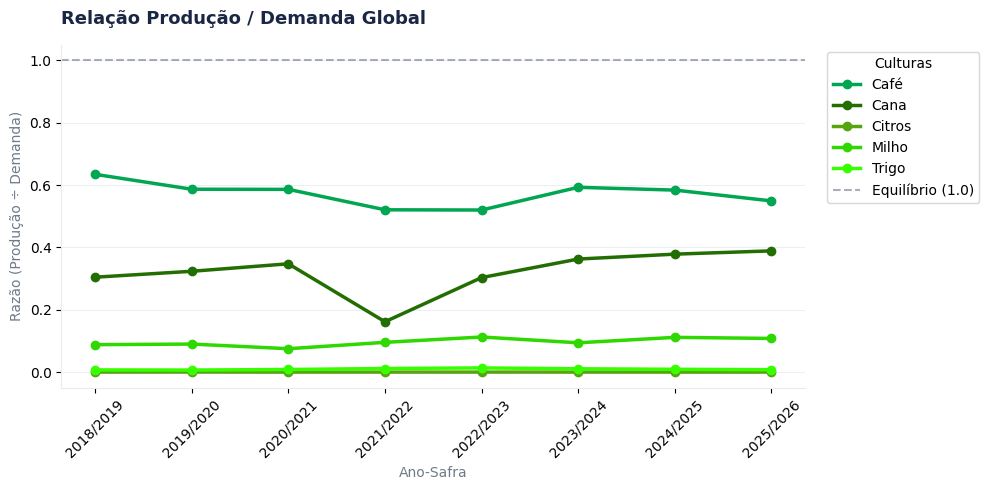

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Identidade Visual L.E.K.
LEK_NAVY = "#1A2744"
LEK_GRAY = "#6E7B8B"
LEK_LIGHT_GRAY = "#E8ECEF"
LEK_BG = "#FFFFFF"
LEK_GREEN = "#00A651"

CROP_COLORS = {
    "Cafe": "#073700",
    "Cana": "#236E03",
    "Citros": "#57A50E",
    "Milho": "#2fd800",
    "Trigo": "#38ff00"
}

def get_crop_color(lbl):
    for k, v in CROP_COLORS.items():
        if k.lower() in str(lbl).lower(): return v
    return LEK_GREEN

# 1. Carregar os Dados (Lê do Excel original diretamente)
df = pd.read_excel("Base LEK.xlsx", sheet_name='Base Geral')

df.columns = df.columns.astype(str).str.strip()
if 'Commodities' in df.columns: 
    df = df.rename(columns={'Commodities': 'cultura'})

# Função para garantir que os valores numéricos estão limpos
def clean_val(v):
    if isinstance(v, str): return v.replace('.', '').replace(',', '.')
    return v

df['Demanda (Global) (1000 t)'] = pd.to_numeric(df['Demanda (Global) (1000 t)'].apply(clean_val), errors='coerce')
df['Produção (mil t)'] = pd.to_numeric(df['Produção (mil t)'].apply(clean_val), errors='coerce')
df['ano_int'] = df['Ano'].astype(str).str.split('/').str[0].apply(pd.to_numeric, errors='coerce')

# Remover linhas nulas
df = df.dropna(subset=['Ano', 'cultura', 'Demanda (Global) (1000 t)', 'Produção (mil t)'])

# Calcular a Relação Produção / Demanda
df['Producao_sobre_Demanda'] = df['Produção (mil t)'] / df['Demanda (Global) (1000 t)']

# Ordenar cronologicamente
df_sorted = df.sort_values(['cultura', 'ano_int'])

# --- GRÁFICO: PRODUÇÃO SOBRE DEMANDA ---
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(LEK_BG)

for cultura in df_sorted['cultura'].unique():
    subset = df_sorted[df_sorted['cultura'] == cultura]
    ax.plot(subset['Ano'], subset['Producao_sobre_Demanda'], marker='o', label=cultura, color=get_crop_color(cultura), linewidth=2.5)

# Linha Tracejada de Break-even (Onde Produção = Demanda)
ax.axhline(1, color=LEK_GRAY, linewidth=1.5, linestyle='--', alpha=0.6, label='Equilíbrio (1.0)')

# Estilização
ax.set_title("Relação Produção / Demanda Global", fontsize=13, fontweight='bold', color=LEK_NAVY, loc='left', pad=15)
ax.set_facecolor(LEK_BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(LEK_LIGHT_GRAY)
ax.spines["bottom"].set_color(LEK_LIGHT_GRAY)
ax.grid(True, color=LEK_LIGHT_GRAY, linewidth=0.6, axis="y")
ax.set_xlabel("Ano-Safra", fontsize=10, color=LEK_GRAY)
ax.set_ylabel("Razão (Produção ÷ Demanda)", fontsize=10, color=LEK_GRAY)

# Ajuste da legenda e eixos
ax.legend(title="Culturas", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("producao_sobre_demanda.png", dpi=300) # Salva apenas como imagem PNG
print("Imagem 'producao_sobre_demanda.png' gerada com sucesso!")